# Library

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.8 MB/s eta 0:00:00


In [ ]:
!pip install cartopy

In [ ]:
# Import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import statsmodels.api as sm
import optuna
from numpy import mean
from numpy import std
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from scipy.spatial import distance_matrix
from sklearn.neighbors import NearestNeighbors
from libpysal.weights import KNN
from esda.moran import Moran
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from optuna.samplers import TPESampler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# Import Data

In [ ]:
# 1) Baca Excel (sheet pertama)
df = pd.read_excel("/content/Data Skripsi Full.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583 entries, 0 to 1582
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitude       1583 non-null   float64
 1   Latitude        1583 non-null   float64
 2   periode         1583 non-null   object 
 3   id_wpp_tangkap  1583 non-null   int64  
 4   so              1583 non-null   float64
 5   thetao          1583 non-null   float64
 6   zos             1583 non-null   float64
 7   uo              1583 non-null   float64
 8   vo              1583 non-null   float64
 9   chl             1583 non-null   float64
 10  o2              1583 non-null   float64
 11  mlotst          1583 non-null   float64
 12  nppv            1583 non-null   float64
 13  Kecepatan       1583 non-null   float64
 14  cpue            1583 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 185.6+ KB


In [ ]:
WPP = pd.read_csv("/content/WPP 572_573.csv", sep =';')

In [ ]:
WPP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         610 non-null    int64  
 1   left       610 non-null    float64
 2   top        610 non-null    float64
 3   right      610 non-null    float64
 4   bottom     610 non-null    float64
 5   row_index  610 non-null    int64  
 6   col_index  610 non-null    int64  
 7   Longitude  610 non-null    float64
 8   Latitude   610 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 43.0 KB


## Missing value


In [ ]:
df.isna().sum()

,0
Longitude,0
Latitude,0
periode,0
id_wpp_tangkap,0
so,0
thetao,0
zos,0
uo,0
vo,0
chl,0


## Statistik Deskriptif

In [ ]:
df.describe()

,Longitude,Latitude,id_wpp_tangkap,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue
count,1583.000000,1583.000000,1583.00000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000
mean,107.438566,-6.699779,572.55338,33.748653,28.665461,0.512219,-0.148165,-0.025906,0.237774,202.593894,19.631813,13.192651,0.221479,9.460825
std,9.551575,4.733729,0.49730,0.529785,1.016045,0.123111,0.221723,0.077974,0.306409,3.883281,6.623713,20.651308,0.169693,17.319075
min,92.250000,-13.750000,572.00000,31.114102,25.918408,0.202413,-0.768959,-0.607629,0.081074,178.812339,10.167482,1.421484,0.001650,0.000072
25%,98.750000,-10.250000,572.00000,33.503919,27.750721,0.443752,-0.338380,-0.059650,0.097566,199.831996,14.537267,2.926775,0.079997,0.423073
50%,106.750000,-8.250000,573.00000,33.787042,28.890697,0.525577,-0.089148,-0.022437,0.117965,200.830212,17.921148,4.364353,0.159137,1.843771
75%,116.250000,-3.250000,573.00000,34.089295,29.334334,0.585140,0.030773,0.020959,0.239142,204.961210,23.394699,13.523554,0.348778,8.691877
max,125.750000,5.750000,573.00000,34.961383,30.496962,0.773223,0.344260,0.263403,3.971957,219.270573,43.532678,215.510166,0.769938,99.604130


## Eksplorasi Scatter Plot

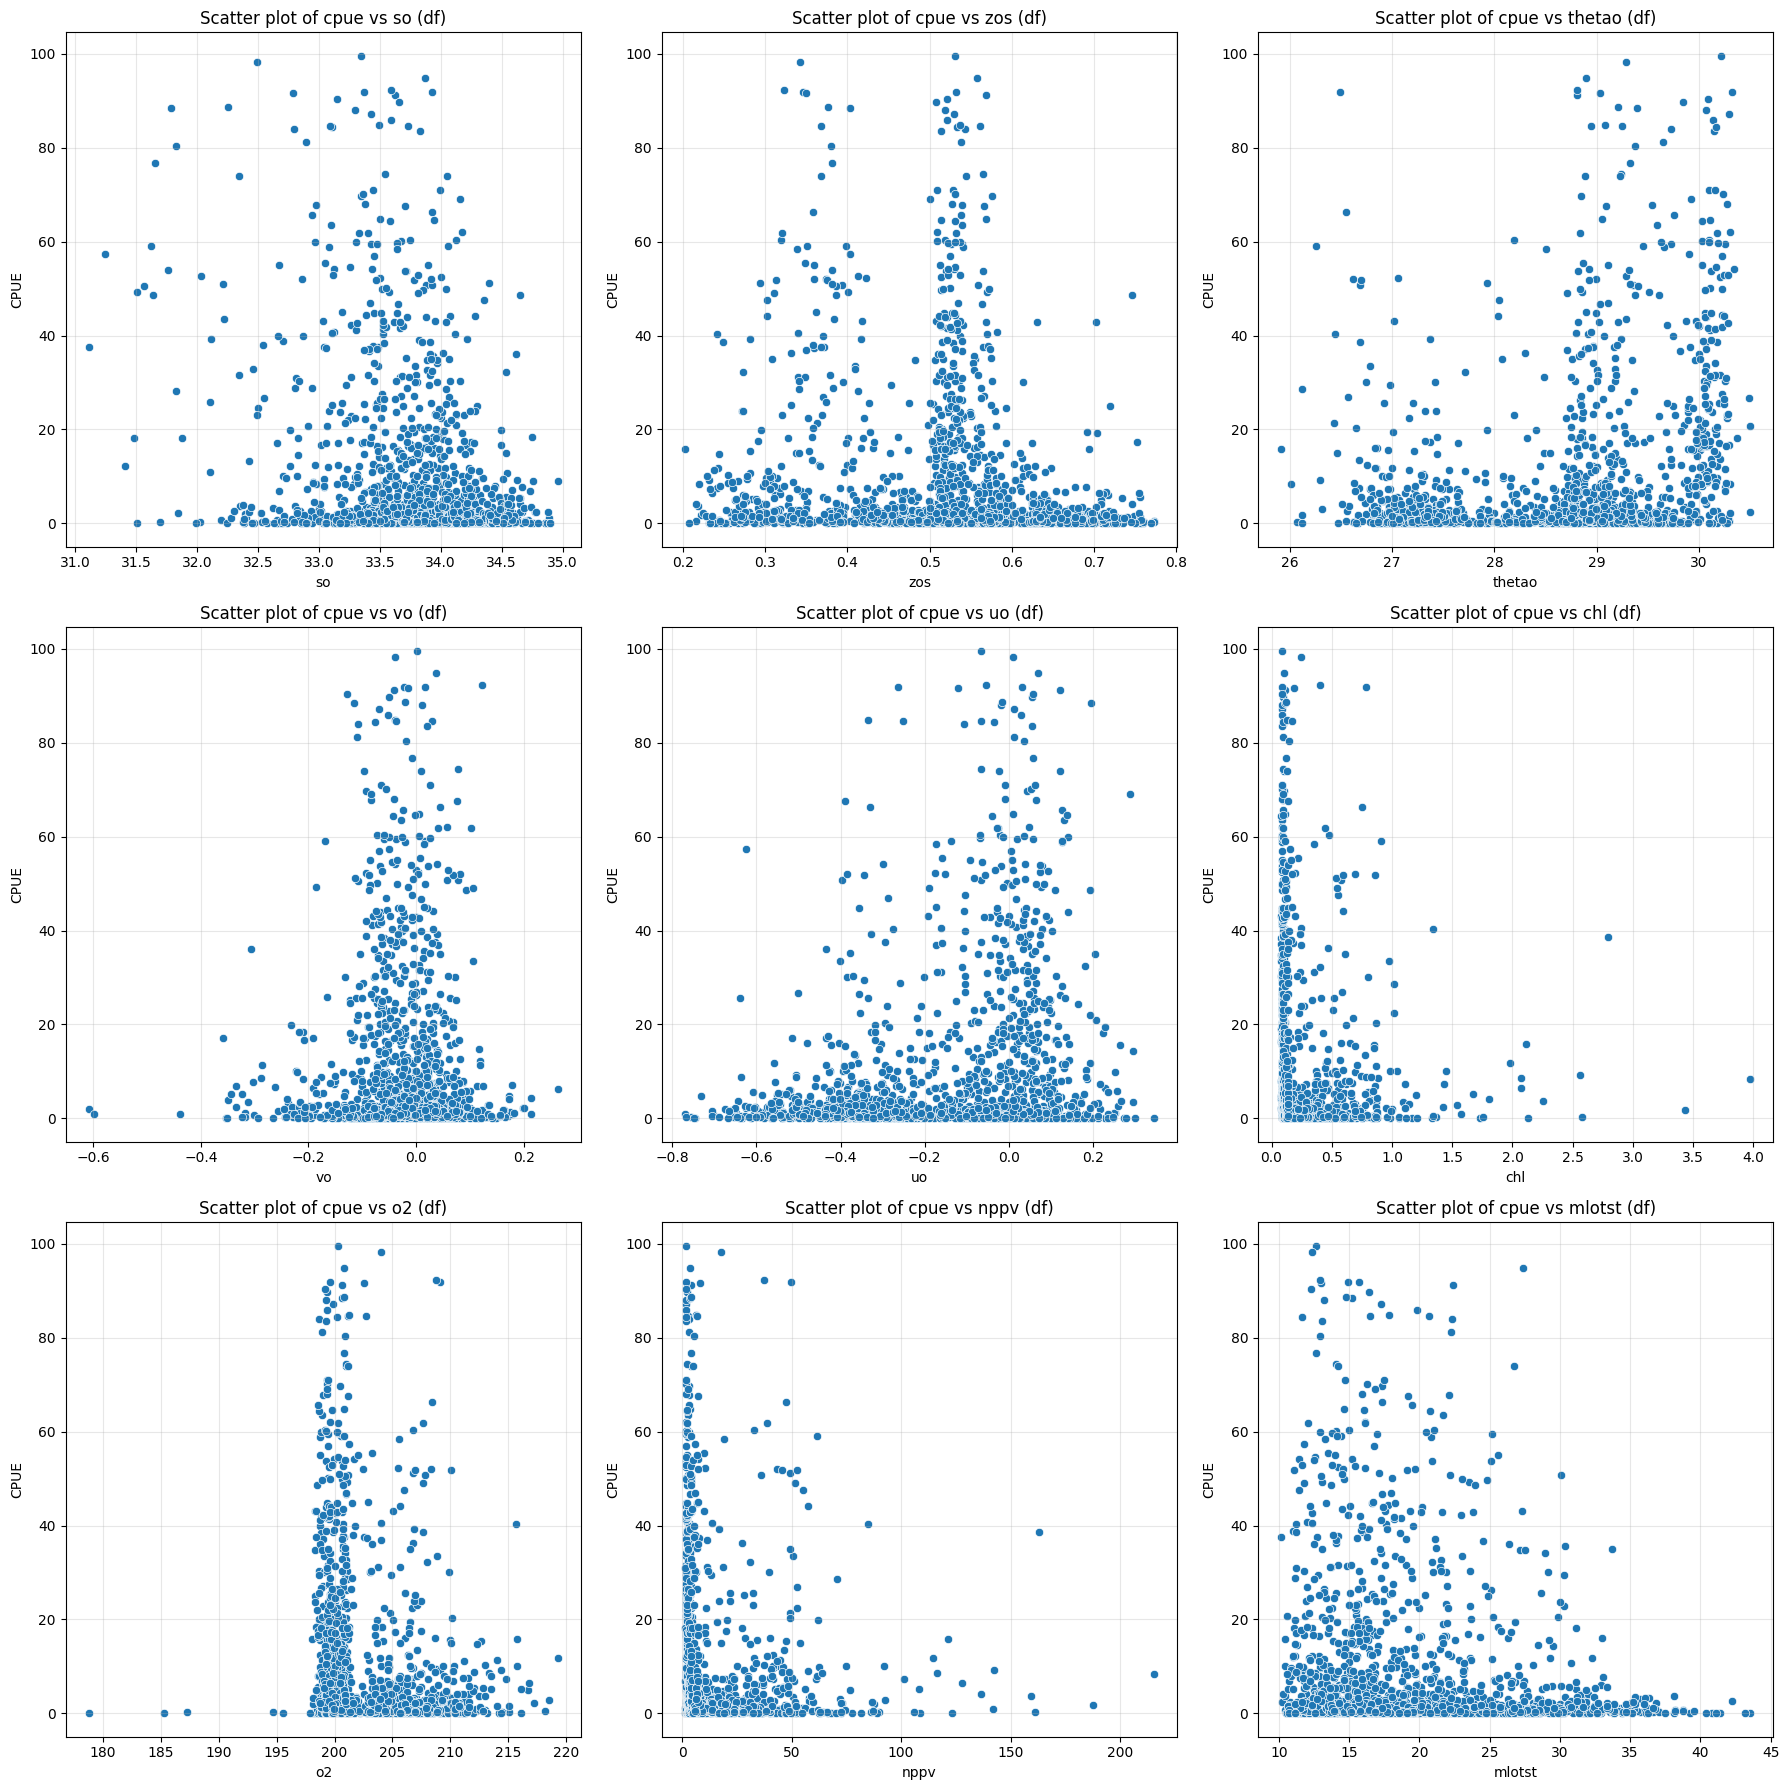

In [ ]:
environmental_vars = ['so', 'zos', 'thetao', 'vo', 'uo', 'chl', 'o2', 'nppv', 'mlotst']

plt.figure(figsize=(18, 18)) # Adjust figure size to accommodate more plots
for i, var in enumerate(environmental_vars):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.scatterplot(data=df, x=var, y='cpue')
    plt.title(f'Scatter plot of cpue vs {var} (df)')
    plt.xlabel(var)
    plt.ylabel('CPUE')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Eksplorasi Boxplot

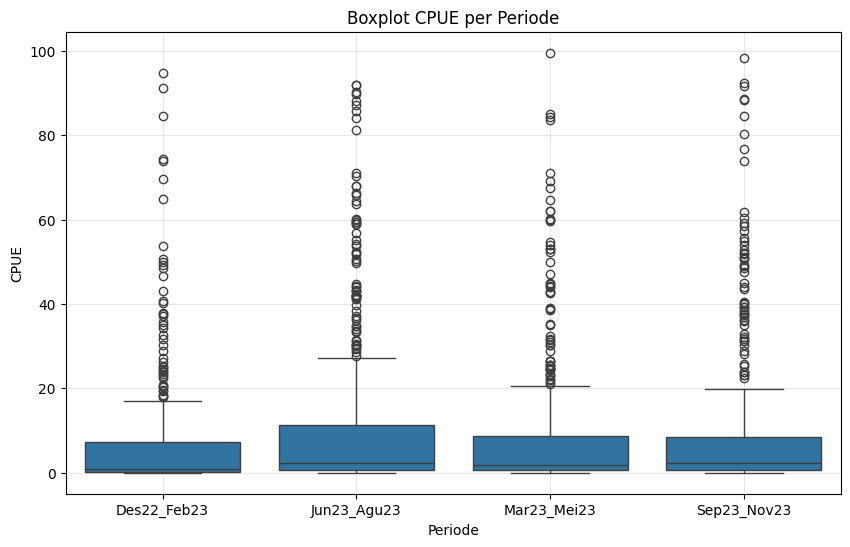

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='periode', y='cpue')
plt.title('Boxplot CPUE per Periode')
plt.xlabel('Periode')
plt.ylabel('CPUE')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df['cpue_transformed'] = np.log1p(df['cpue'])
df.head()

,Longitude,Latitude,periode,id_wpp_tangkap,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue,cpue_transformed
0,92.25,2.75,Des22_Feb23,572,33.962241,28.953252,0.536405,-0.141075,0.010665,0.107391,201.216329,16.318926,4.061032,0.141477,18.318995,2.961089
1,92.25,3.25,Des22_Feb23,572,33.930846,29.062583,0.542085,-0.158578,0.032903,0.100964,201.194042,16.306210,3.584600,0.161955,15.934011,2.829324
2,92.75,1.25,Des22_Feb23,572,34.041546,28.774475,0.531435,0.012558,-0.054329,0.126704,201.143570,18.354906,5.410838,0.055761,9.870458,2.386049
3,93.25,0.75,Des22_Feb23,572,34.077844,28.788351,0.535326,0.112574,-0.022284,0.115972,201.043730,23.588266,4.681760,0.114758,30.287245,3.443210
4,93.25,1.25,Des22_Feb23,572,34.020678,28.805373,0.535775,0.023030,-0.028128,0.117965,201.124162,19.194165,4.774173,0.036353,18.029441,2.945987


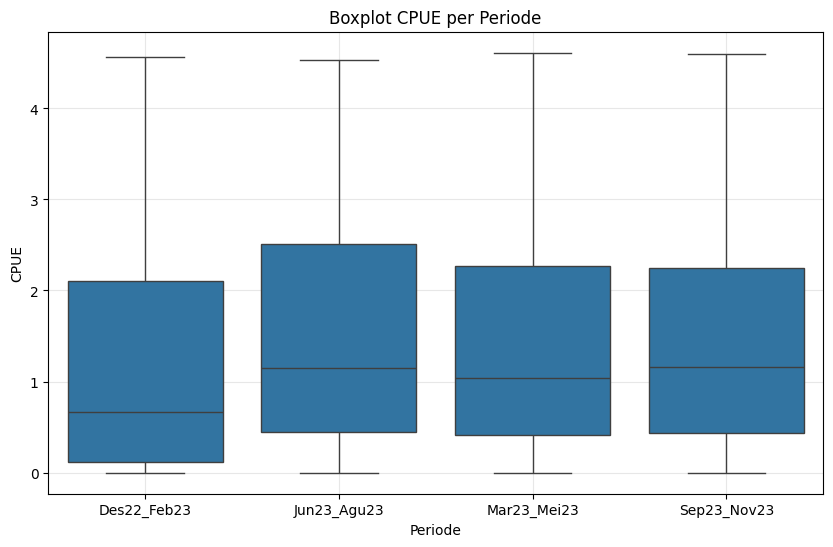

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='periode', y='cpue_transformed')
plt.title('Boxplot CPUE per Periode')
plt.xlabel('Periode')
plt.ylabel('CPUE')
plt.grid(alpha=0.3)
plt.show()

# Juni 2023 - Agustus 2023 (Setelah Penanganan Pencilan)

In [ ]:
# 1) Baca Excel (sheet pertama)
data = pd.read_excel("/content/Juni 2023 -Agustus 2023.xlsx")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 437 entries, 0 to 441
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitude       437 non-null    float64
 1   Latitude        437 non-null    float64
 2   periode         437 non-null    object 
 3   id_wpp_tangkap  437 non-null    int64  
 4   cpue            437 non-null    float64
 5   n_trip          437 non-null    int64  
 6   so              437 non-null    float64
 7   thetao          437 non-null    float64
 8   zos             437 non-null    float64
 9   uo              437 non-null    float64
 10  vo              437 non-null    float64
 11  chl             437 non-null    float64
 12  o2              437 non-null    float64
 13  mlotst          437 non-null    float64
 14  nppv            437 non-null    float64
 15  Kecepatan       437 non-null    float64
 16  cpue_new        437 non-null    float64
dtypes: float64(14), int64(2), object(1)
memo

In [ ]:
data.describe()

,Longitude,Latitude,id_wpp_tangkap,cpue,n_trip,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue_new
count,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000
mean,107.761442,-6.776316,572.562929,16.177655,24.897025,33.642088,28.122198,0.506604,-0.217160,-0.043992,0.266541,203.173003,24.158821,14.361573,0.263935,11.244578
std,9.707647,4.816697,0.496593,65.132576,85.199313,0.314378,1.273857,0.077406,0.218737,0.075825,0.246646,3.234920,7.222374,16.136575,0.181605,19.421045
min,92.250000,-13.750000,572.000000,0.000121,1.000000,31.995181,26.075140,0.311464,-0.656911,-0.607629,0.081074,198.115852,10.587781,1.579745,0.010753,0.000121
25%,98.750000,-10.750000,572.000000,0.556174,3.000000,33.500139,27.109921,0.459205,-0.390535,-0.069713,0.093513,199.484450,18.653027,2.728855,0.085744,0.556174
50%,107.250000,-8.750000,573.000000,2.161249,8.000000,33.696264,27.406147,0.507820,-0.240588,-0.039273,0.161179,204.058398,23.099404,7.605413,0.247480,2.161249
75%,116.750000,-3.750000,573.000000,11.311936,22.000000,33.849916,29.585691,0.536996,-0.013807,-0.003917,0.306275,205.350831,29.409389,18.597525,0.399315,11.311936
max,125.750000,5.750000,573.000000,1241.528882,1533.000000,34.490606,30.496962,0.724060,0.215838,0.119836,1.361712,211.272738,43.532678,90.109225,0.665446,91.873172


## Eksplorasi Scatter Plot

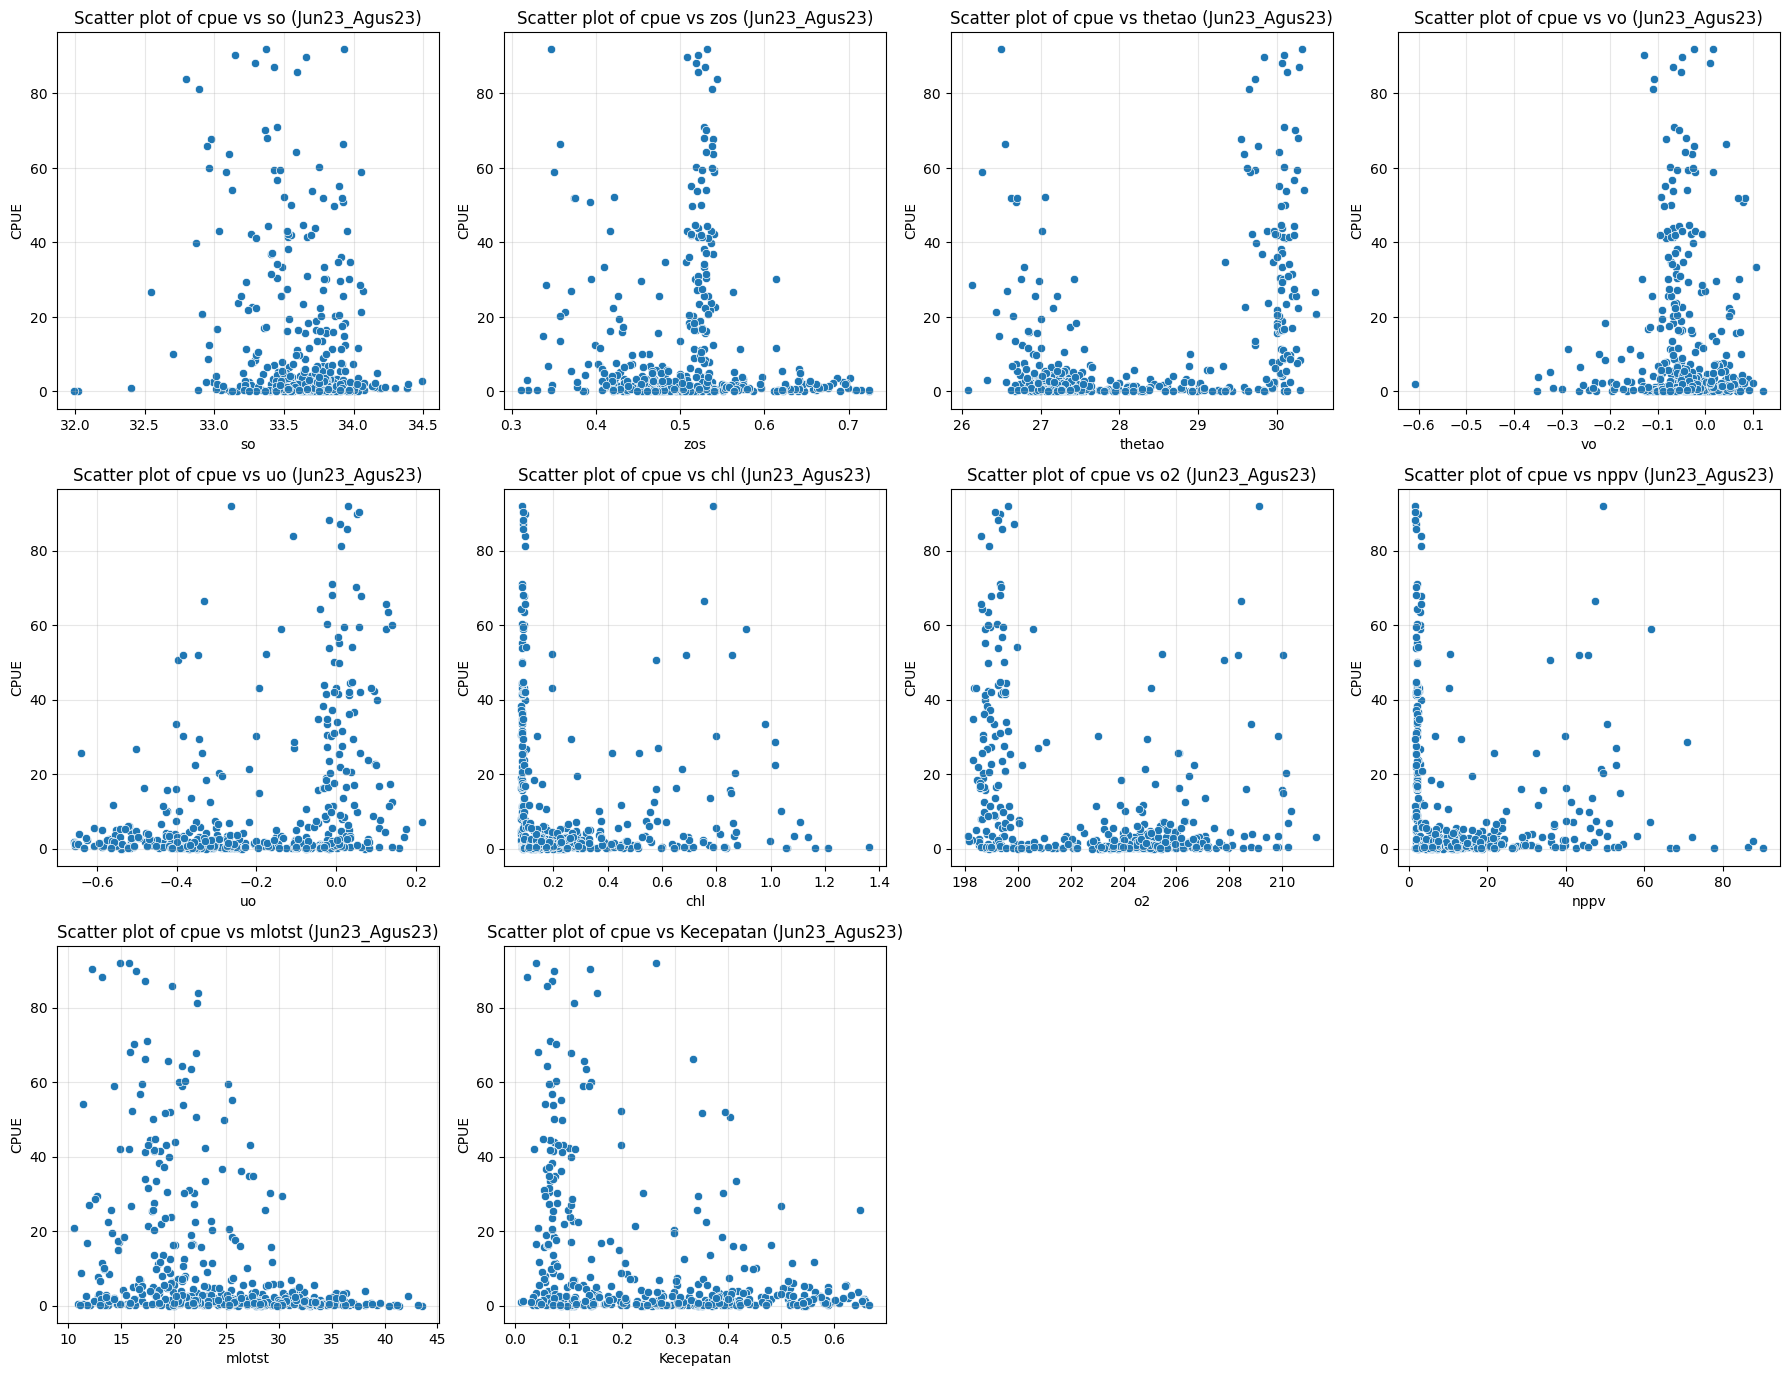

In [ ]:
environmental_vars = ['so', 'zos', 'thetao', 'vo', 'uo', 'chl', 'o2', 'nppv', 'mlotst', 'Kecepatan']

plt.figure(figsize=(18, 18)) # Adjust figure size to accommodate more plots
for i, var in enumerate(environmental_vars):
    plt.subplot(4, 4, i + 1) # Arrange plots in a 3x3 grid
    sns.scatterplot(data=data, x=var, y='cpue_new')
    plt.title(f'Scatter plot of cpue vs {var} (Jun23_Agus23)')
    plt.xlabel(var)
    plt.ylabel('CPUE')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Eksplorasi Peta Spasial

In [ ]:
cpue_jun2 = pd.merge(
    WPP,
    data[['Longitude', 'Latitude', 'cpue_new']],
    on=['Longitude', 'Latitude'],
    how='left'
)

In [ ]:
cpue_jun2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         610 non-null    int64  
 1   left       610 non-null    float64
 2   top        610 non-null    float64
 3   right      610 non-null    float64
 4   bottom     610 non-null    float64
 5   row_index  610 non-null    int64  
 6   col_index  610 non-null    int64  
 7   Longitude  610 non-null    float64
 8   Latitude   610 non-null    float64
 9   cpue_new   437 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 47.8 KB


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


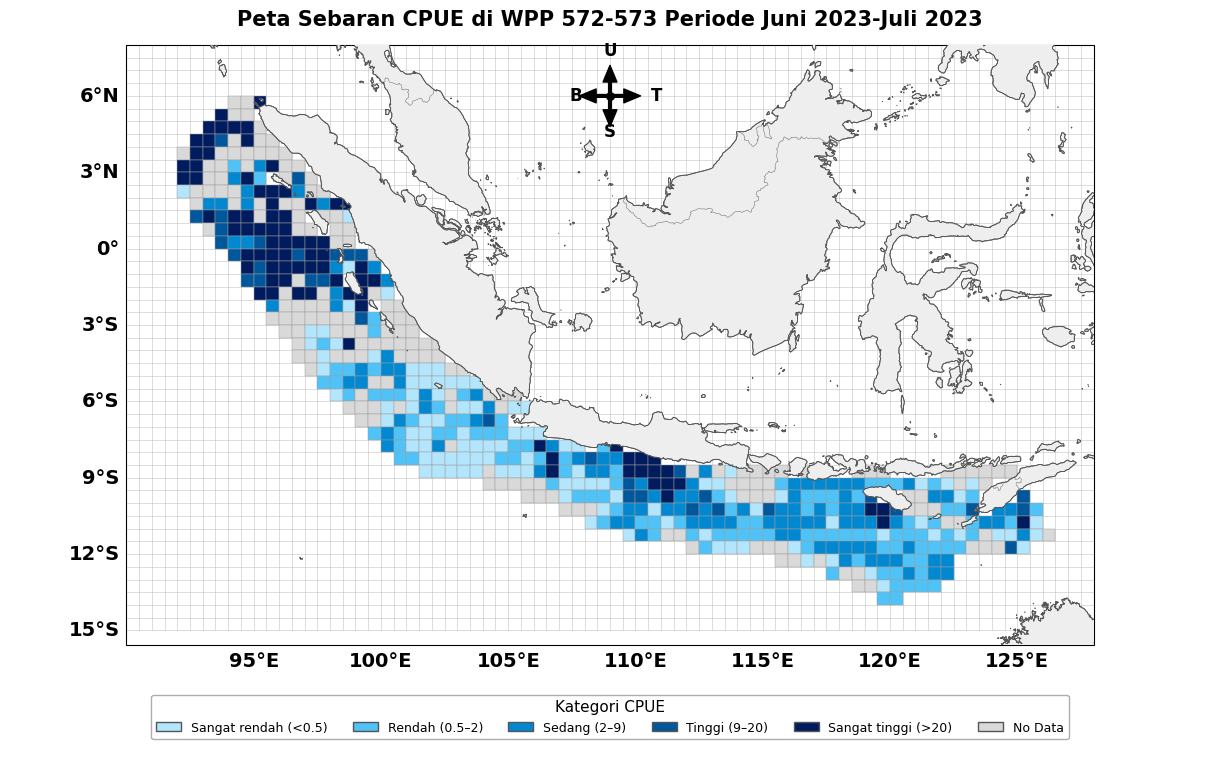

In [ ]:
# =========================
# 1. PARAMETER
# =========================
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = cpue_jun2.copy()

plot_data['cpue_new'] = pd.to_numeric(
    plot_data['cpue_new'],
    errors='coerce'
)

# =========================
# 2. KATEGORI CPUE + NO DATA
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

plot_data['kategori_cpue'] = pd.cut(
    plot_data['cpue_new'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plot_data['kategori_cpue'] = (
    plot_data['kategori_cpue']
    .cat.add_categories(['No Data'])
)

plot_data['kategori_cpue'] = (
    plot_data['kategori_cpue']
    .fillna('No Data')
)

# =========================
# 3. WARNA
# =========================
colors_cpue = {
    'Sangat rendah (<0.5)': '#B3E5FC',
    'Rendah (0.5–2)': '#4FC3F7',
    'Sedang (2–9)': '#0288D1',
    'Tinggi (9–20)': '#01579B',
    'Sangat tinggi (>20)': '#001B5E',
    'No Data': '#d9d9d9'
}

# =========================
# 4. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.10, 0.02, 0.80, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 5. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 6. PLOT GRID CPUE
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    kategori = row['kategori_cpue']

    if pd.isna(lon) or pd.isna(lat):
        continue

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=colors_cpue[kategori],
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 7. DARATAN
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 8. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 14,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 14,
    'weight': 'bold'
}

# =========================
# 9. LEGENDE HORIZONTAL
# =========================
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[label],
        edgecolor='#555555',
        label=label
    )
    for label in colors_cpue
]

legend_ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='center',
    ncol=6,
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 10. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 11. JUDUL
# =========================
ax.set_title(
    'Peta Sebaran CPUE di WPP 572-573 Periode Juni 2023-Juli 2023',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

In [ ]:
np.random.seed(42)

# Definisikan koordinat dari DataFrame 'data'
coords_cpue_new = list(zip(data['Longitude'], data['Latitude']))

# Buat matriks bobot spasial K-nearest neighbors (misalnya, k=4)
w_cpue_new = KNN.from_array(coords_cpue_new, k=5)

# Standardisasi baris matriks bobot
w_cpue_new.transform = 'R'

# Hitung Moran's I untuk cpue_new
mi_cpue_new = Moran(data['cpue_new'], w_cpue_new)

print("Moran's I (cpue_new):", mi_cpue_new.I)
print("p-value (cpue_new)  :", mi_cpue_new.p_sim)
print("z-score (cpue_new)  :", mi_cpue_new.z_sim)

Moran's I (cpue_new): 0.5735604812276724
p-value (cpue_new)  : 0.001
z-score (cpue_new)  : 20.151092661127276


## Eksplorasi Boxplot

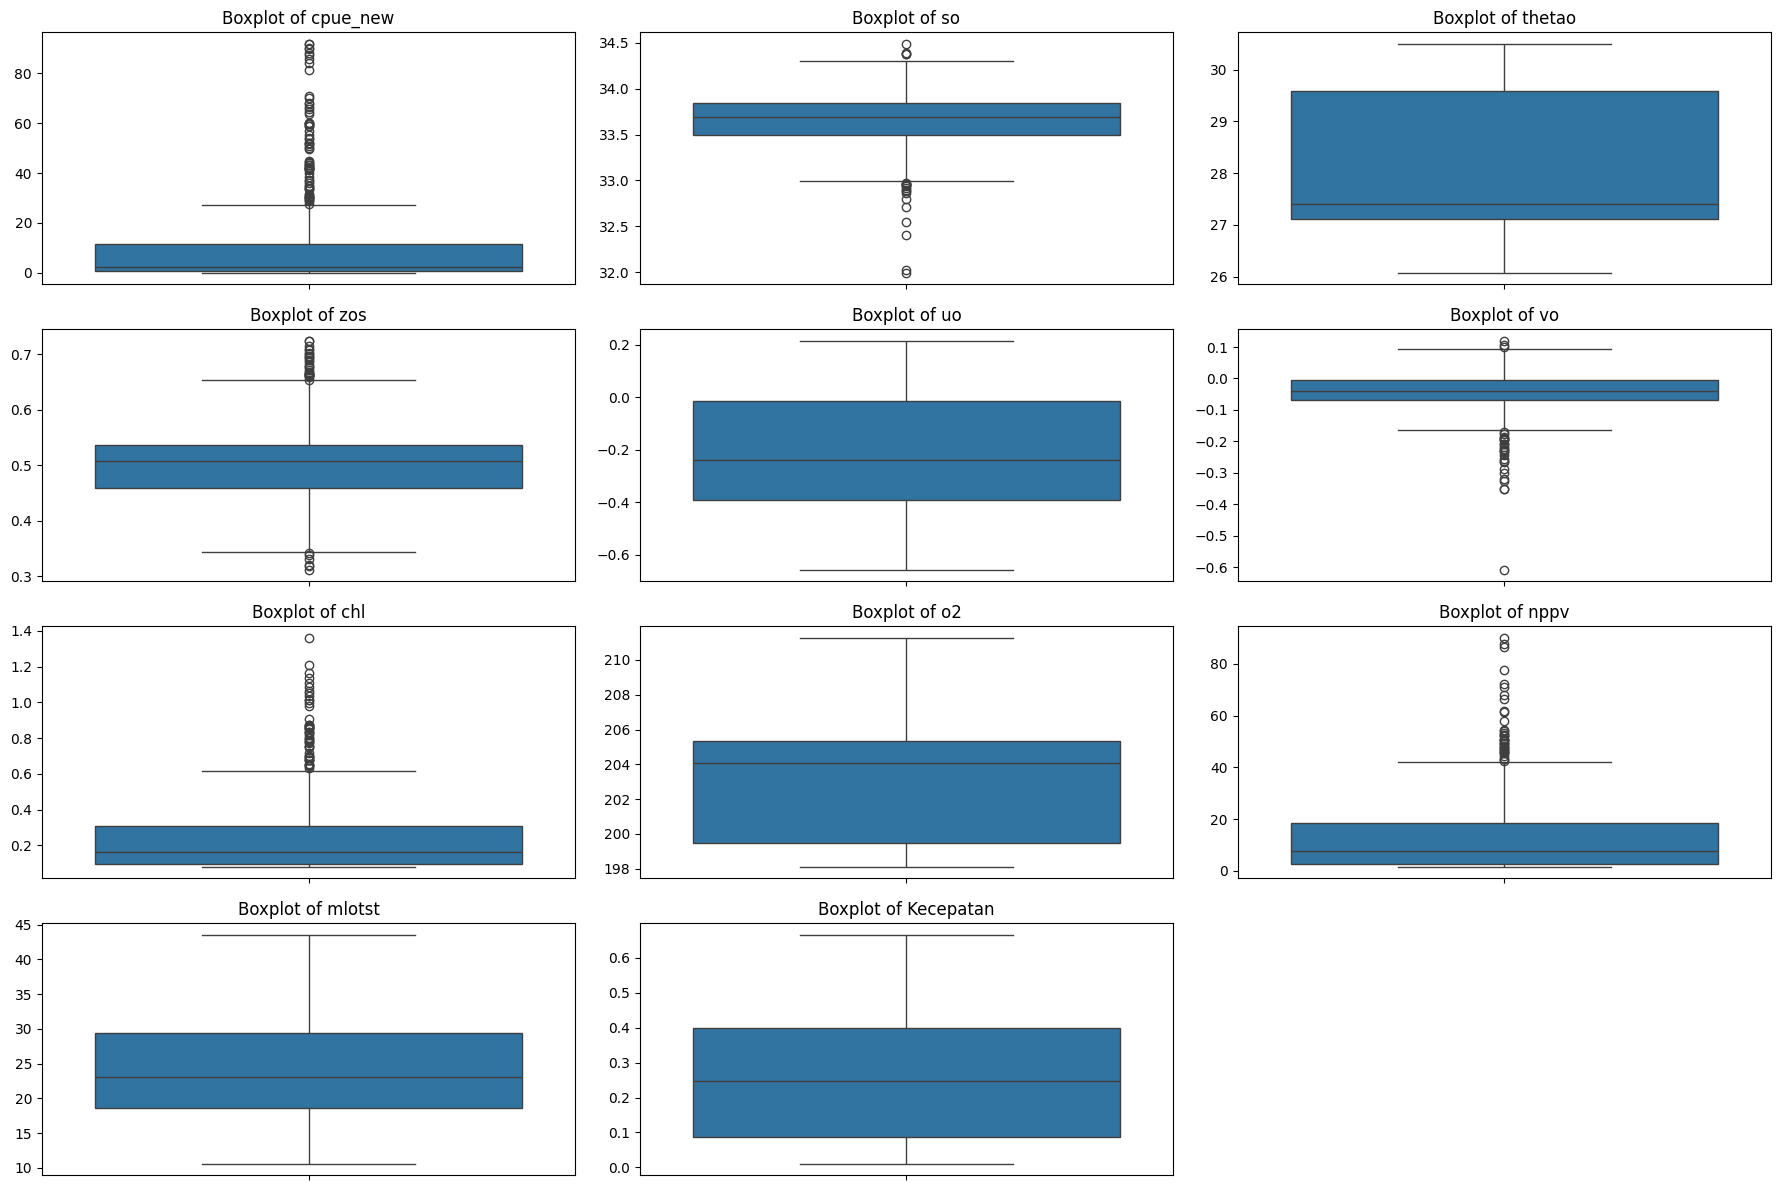

In [ ]:
columns_to_plot = ['cpue_new', 'so', 'thetao', 'zos', 'uo', 'vo', 'chl', 'o2',  'nppv', 'mlotst', 'Kecepatan']

plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_plot):
    plt.subplot(4, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter
plt.tight_layout()
plt.show()

## Pemodelan Regresi Linear Berganda

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']

# Add a constant (intercept) to the independent variables
X = sm.add_constant(X)
VarNames = X.columns[:]

In [ ]:
# Model regresi
model = sm.OLS(y, X).fit()

# Ringkasan hasil
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               cpue_new   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     21.97
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.21e-30
Time:                        08:40:29   Log-Likelihood:                -1832.7
No. Observations:                 437   AIC:                             3685.
Df Residuals:                     427   BIC:                             3726.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         91.8554    259.841      0.354      0.7

In [ ]:
# pastikan X punya konstanta
X_const = sm.add_constant(X, has_constant="add")

# model regresi
model = sm.OLS(y, X_const).fit()

# residual
residual = model.resid

# Breusch-Pagan
bp_test = het_breuschpagan(residual, X_const)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

if bp_test[1] < 0.05:
    print("Terdapat heteroskedastisitas")
else:
    print("Tidak terdapat heteroskedastisitas")

Breusch-Pagan Test
LM Statistic: 64.31433339904603
LM p-value: 5.481256038718884e-10
F Statistic: 8.187483693060031
F p-value: 2.95999887263608e-11
Terdapat heteroskedastisitas


In [ ]:
# residual/sisaan dari model OLS
residual = model.resid

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I residual
moran_resid = Moran(residual, w)

print("Moran's I:", moran_resid.I)
print("Expected I:", moran_resid.EI)
print("p-value:", moran_resid.p_sim)
print("z-score:", moran_resid.z_sim)

if moran_resid.p_sim < 0.05:
    print("Terdapat autokorelasi spasial pada sisaan")
else:
    print("Tidak terdapat autokorelasi spasial pada sisaan")

Moran's I: 0.32729092630066087
Expected I: -0.0022935779816513763
p-value: 0.001
z-score: 11.368788584349865
Terdapat autokorelasi spasial pada sisaan


## XGBoost Global (Tanpa Longitude/Latitude)

### Pemodelan XGBoost Transformasi Log

#### Pembagian data

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
# 1. Stratified binning (pakai y asli)
y_binned = pd.qcut(y, q=5, labels=False)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y_binned, test_size=0.3, random_state=42
)

In [ ]:
print("TRAIN")
print(pd.Series(y_train).describe())

print("\nTEST")
print(pd.Series(y_test).describe())

TRAIN
count    305.000000
mean      11.311176
std       19.413790
min        0.000121
25%        0.556174
50%        2.275134
75%       11.515534
max       91.873172
Name: cpue_new, dtype: float64

TEST
count    132.000000
mean      11.090698
std       19.510918
min        0.001856
25%        0.625068
50%        1.914061
75%       10.325000
max       91.854982
Name: cpue_new, dtype: float64


In [ ]:
# 3. Transformasi (SETELAH split)
y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

#### Optuna Tuning Hyperparameter

In [ ]:
def objective(trial):

    params = {
        'objective': 'reg:squarederror',

        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 75, 100]
        ),

        'max_depth': trial.suggest_categorical(
            'max_depth', [2, 3, 4]
        ),

        'learning_rate': trial.suggest_categorical(
            'learning_rate', [0.01, 0.03, 0.05]
        ),

        'subsample': trial.suggest_categorical(
            'subsample', [0.6, 0.7, 0.8, 0.9]
        ),

        'colsample_bytree': trial.suggest_categorical(
            'colsample_bytree', [0.6, 0.7, 0.8]
        ),

        'gamma': trial.suggest_categorical(
            'gamma', [0.1, 0.3, 0.5, 1]
        ),

        'reg_alpha': trial.suggest_categorical(
            'reg_alpha',  [0.5, 1, 2, 5]
        ),

        'reg_lambda': trial.suggest_categorical(
            'reg_lambda', [1, 2, 3, 5]
        ),

        'min_child_weight': trial.suggest_categorical(
            'min_child_weight', [5, 7, 10, 13]
        ),

        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBRegressor(**params)

    # 🔥 BINNING target untuk stratification
    y_binned = pd.qcut(y_train, q=5, labels=False, duplicates='drop')

    # 🔥 Stratified K-Fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring= 'neg_root_mean_squared_error',
        cv=cv.split(X_train, y_binned),  # <- ini kuncinya
        n_jobs=1
    )

    return -scores.mean()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=100)

[I 2026-04-30 08:51:48,570] A new study created in memory with name: no-name-70753463-7d94-489d-ac7f-b7c8ae90f031
[I 2026-04-30 08:51:49,175] Trial 0 finished with value: 0.9876999991333753 and parameters: {'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.6, 'gamma': 0.3, 'reg_alpha': 0.5, 'reg_lambda': 2, 'min_child_weight': 10}. Best is trial 0 with value: 0.9876999991333753.
[I 2026-04-30 08:51:49,755] Trial 1 finished with value: 1.0602153465831727 and parameters: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.6, 'gamma': 0.5, 'reg_alpha': 0.5, 'reg_lambda': 5, 'min_child_weight': 10}. Best is trial 0 with value: 0.9876999991333753.
[I 2026-04-30 08:51:50,320] Trial 2 finished with value: 1.0706532169994074 and parameters: {'n_estimators': 75, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.7, 'gamma': 0.1, 'reg_alpha': 2, 'reg_lambda': 1, 'min_chil

In [ ]:
best_params = study.best_params
best_params

{'n_estimators': 100,
 'max_depth': 4,
 'learning_rate': 0.05,
 'subsample': 0.7,
 'colsample_bytree': 0.6,
 'gamma': 0.1,
 'reg_alpha': 2,
 'reg_lambda': 2,
 'min_child_weight': 10}

In [ ]:
best_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42
)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_train_log = best_model.predict(X_train)
y_pred_test_log = best_model.predict(X_test)

# inverse transform
y_pred_train = np.expm1(y_pred_train_log)
y_pred_test = np.expm1(y_pred_test_log)

# target asli
y_train_asli = np.expm1(y_train)
y_test_asli = np.expm1(y_test)

#### Evaluasi Model

In [ ]:
def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

# Train
r2_train, mae_train, rmse_train = evaluate(y_train_asli, y_pred_train)

# Test
r2_test, mae_test, rmse_test = evaluate(y_test_asli, y_pred_test)

print("=== TRAIN ===")
print("MAE:", mae_train)
print("RMSE:", rmse_train)

print("\n=== TEST ===")
print("MAE:", mae_test)
print("RMSE:", rmse_test)

=== TRAIN ===
MAE: 6.169429437528159
RMSE: 13.248339492293448

=== TEST ===
MAE: 8.199859337936708
RMSE: 15.987886751399934


In [ ]:
y_pred = best_model.predict(X)
residual = y - y_pred

from libpysal.weights import KNN

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

In [ ]:
np.random.seed(42)
mi = Moran(residual, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.5466058608567701
p-value   : 0.001
z-score   : 19.227474314110093


### Pemodelan XGBoost Tweedie

#### Pembagian Data

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
# 1. Stratified binning (pakai y asli)
y_binned = pd.qcut(y, q=5, labels=False)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y_binned, test_size=0.3, random_state=42
)

In [ ]:
print("TRAIN")
print(pd.Series(y_train).describe())

print("\nTEST")
print(pd.Series(y_test).describe())

TRAIN
count    305.000000
mean      11.311176
std       19.413790
min        0.000121
25%        0.556174
50%        2.275134
75%       11.515534
max       91.873172
Name: cpue_new, dtype: float64

TEST
count    132.000000
mean      11.090698
std       19.510918
min        0.001856
25%        0.625068
50%        1.914061
75%       10.325000
max       91.854982
Name: cpue_new, dtype: float64


#### Optuna Tuning Hyperparameter

In [ ]:
def objective(trial):

    params = {
        'objective': 'reg:tweedie',
        'eval_metric': 'rmse',

        # Tweedie power umumnya 1 < p < 2
        # p mendekati 1: mirip Poisson
        # p mendekati 2: mirip Gamma
        'tweedie_variance_power': trial.suggest_float(
            'tweedie_variance_power', 1.1, 1.9
        ),

        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 75, 100]
        ),

        'max_depth': trial.suggest_categorical(
            'max_depth', [2, 3]
        ),

        'learning_rate': trial.suggest_categorical(
            'learning_rate', [0.01, 0.03, 0.05]
        ),

        'subsample': trial.suggest_categorical(
            'subsample', [0.6, 0.7, 0.8, 0.9]
        ),

        'colsample_bytree': trial.suggest_categorical(
            'colsample_bytree', [0.6, 0.7, 0.8]
        ),

        'gamma': trial.suggest_categorical(
            'gamma', [0.1, 0.3, 0.5, 1]
        ),

        'reg_alpha': trial.suggest_categorical(
            'reg_alpha',  [0.5, 1, 2, 5]
        ),

        'reg_lambda': trial.suggest_categorical(
            'reg_lambda', [1, 2, 3, 5]
        ),

        'min_child_weight': trial.suggest_categorical(
            'min_child_weight', [5, 7, 10, 13]),

        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBRegressor(**params)

    y_binned = pd.qcut(y_train, q=5, labels=False, duplicates='drop')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=cv.split(X_train, y_binned),
        n_jobs=1
    )

    return -scores.mean()

In [ ]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=100)

[I 2026-04-30 08:57:59,013] A new study created in memory with name: no-name-f8fe5a3b-8718-4144-ab21-d52bc42af781
[I 2026-04-30 08:57:59,350] Trial 0 finished with value: 15.788530433239885 and parameters: {'tweedie_variance_power': 1.39963209507789, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.6, 'gamma': 0.3, 'reg_alpha': 0.5, 'reg_lambda': 2, 'min_child_weight': 10}. Best is trial 0 with value: 15.788530433239885.
[I 2026-04-30 08:57:59,742] Trial 1 finished with value: 16.44001262878206 and parameters: {'tweedie_variance_power': 1.1520412743882238, 'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.6, 'gamma': 0.5, 'reg_alpha': 0.5, 'reg_lambda': 5, 'min_child_weight': 10}. Best is trial 0 with value: 15.788530433239885.
[I 2026-04-30 08:58:00,419] Trial 2 finished with value: 15.988721419776601 and parameters: {'tweedie_variance_power': 1.3247476077499047, 'n_estimators': 100, 'ma

In [ ]:
best_params = study.best_params
best_params

{'tweedie_variance_power': 1.7459610067040099,
 'n_estimators': 100,
 'max_depth': 2,
 'learning_rate': 0.05,
 'subsample': 0.7,
 'colsample_bytree': 0.8,
 'gamma': 1,
 'reg_alpha': 0.5,
 'reg_lambda': 1,
 'min_child_weight': 5}

In [ ]:
best_model = XGBRegressor(
    **best_params,
    objective='reg:tweedie',
    eval_metric='rmse',
    random_state=42
)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

#### Evaluasi Model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Prediksi
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

# Evaluasi train
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_r2   = r2_score(y_train, y_train_pred)

# Evaluasi test
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)

print("=== TRAIN EVALUATION ===")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")

print("\n=== TEST EVALUATION ===")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")

=== TRAIN EVALUATION ===
RMSE : 12.3005
MAE  : 6.4810

=== TEST EVALUATION ===
RMSE : 15.9383
MAE  : 9.0315


#### Pengecekan Autokorelasi Spasial Residual

In [ ]:
residual2 = y - y_pred

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

In [ ]:
from esda.moran import Moran
np.random.seed(42)
mi = Moran(residual2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.2115905496870536
p-value   : 0.001
z-score   : 7.402009025004697


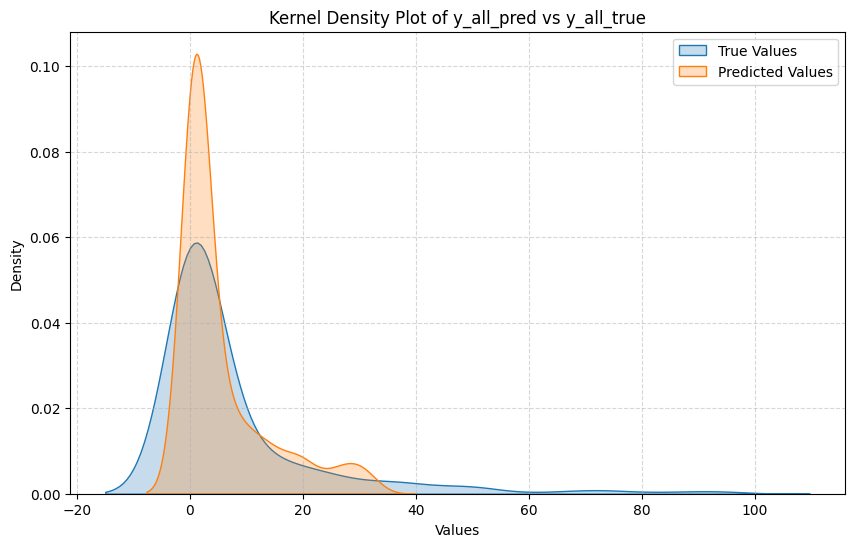

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(y, label='True Values', fill=True)
sns.kdeplot(y_pred, label='Predicted Values', fill=True)
plt.title('Kernel Density Plot of y_all_pred vs y_all_true')
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## XGBoost Lokal Transformasi Logaritma

### Optimasi Bandwith

In [ ]:
def optimize_bw_gw_xgboost(
    X, y, Coords, params,
    bw_min, bw_max, step=1,
    Kernel='Adaptive',              # 'Adaptive' / 'Fixed'
    KernelFunction='Bisquare',      # 'Bisquare' / 'Gaussian'
    spatial_weights=True,
    n_splits=3,
    max_iter=30,
    tol=1e-3,
    path_save=False
):
    """
    Optimasi bandwidth GWXGBoost:
    - Adaptive : Grid Search
    - Fixed    : Golden Section Ratio

    Kriteria bandwidth terbaik:
    - MAE CV terkecil pada skala asli

    Training model:
    - tetap menggunakan y_log = log1p(y)

    Evaluasi hasil terbaik:
    - ditampilkan pada skala asli dan skala log
    """

    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, GridSearchCV
    from sklearn.metrics import (
        r2_score, mean_absolute_error, mean_squared_error
    )
    from xgboost import XGBRegressor

    # =========================================================
    # Helper RMSE
    # =========================================================
    try:
        from sklearn.metrics import root_mean_squared_error
        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # =========================================================
    # Validasi & casting
    # =========================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 karena fungsi ini memakai log1p(y).")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    y_log = pd.Series(np.log1p(y), name='y_log')

    # =========================================================
    # Param grid model (masih bisa Anda perluas)
    # =========================================================
    reg_alpha_list = [params.get('reg_alpha', 0)]
    param_grid = {'reg_alpha': reg_alpha_list}

    # =========================================================
    # Scoring CV
    # refit = MAE asli terkecil
    # =========================================================
    def scorer_neg_mae_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return -mean_absolute_error(y_true_original, y_pred_original)

    def scorer_neg_rmse_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return -rmse_func(y_true_original, y_pred_original)

    def scorer_r2_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return r2_score(y_true_original, y_pred_original)

    scoring = {
        'neg_mean_absolute_error_original': scorer_neg_mae_original,
        'neg_root_mean_squared_error_original': scorer_neg_rmse_original,
        'r2_original': scorer_r2_original
    }

    print("================= Optimizing bandwidth =================")
    print(f"Bandwidth mode : {Kernel}")
    print(f"Kernel function: {KernelFunction}")
    print(f"Spatial weights: {spatial_weights}")
    print("Selection rule : minimum CV-MAE on original scale")

    num_rows = len(X)
    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    if Kernel == 'Adaptive':
        bw_min = int(bw_min)
        bw_max = min(int(bw_max), num_rows - 1)
        step = int(step)
        if bw_min < 1:
            raise ValueError("Untuk Adaptive, bw_min minimal 1.")
        if bw_min > bw_max:
            raise ValueError("Untuk Adaptive, bw_min harus <= bw_max.")
        if step < 1:
            raise ValueError("Untuk Adaptive, step minimal 1.")
    else:
        bw_min = float(bw_min)
        bw_max = float(bw_max)
        if bw_min <= 0 or bw_max <= 0 or bw_min >= bw_max:
            raise ValueError("Untuk Fixed, pastikan 0 < bw_min < bw_max.")

    results_cache = {}

    # =========================================================
    # Bobot kernel
    # =========================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0
        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)
        else:
            raise ValueError("KernelFunction tidak dikenal.")

        return np.asarray(w, dtype=float)

    # =========================================================
    # Format cache key
    # =========================================================
    def bw_key(b):
        if Kernel == 'Adaptive':
            return int(round(b))
        else:
            return round(float(b), 10)

    # =========================================================
    # Evaluasi 1 bandwidth
    # MAE dipakai sebagai objective pemilihan bandwidth
    # =========================================================
    def evaluate_bandwidth(b):
        import numpy as np
        import pandas as pd

        if Kernel == 'Adaptive':
            b_eval = int(round(b))
            b_eval = max(int(bw_min), min(int(bw_max), b_eval))
            bw_label = f"{b_eval:d}"
        else:
            b_eval = float(b)
            if b_eval <= 0:
                result = {
                    'BW': b_eval,

                    'R2_asli': np.nan,
                    'MAE_asli': np.nan,
                    'RMSE_asli': np.nan,

                    'R2_log': np.nan,
                    'MAE_log': np.nan,
                    'RMSE_log': np.nan,

                    'CV_MAE': np.inf,
                    'LMResults': None,
                    'status': 'bw harus > 0'
                }
                print(f"bw={b_eval:.6f}, CV_MAE=inf")
                return result
            bw_label = f"{b_eval:.6f}"

        key = bw_key(b_eval)
        if key in results_cache:
            return results_cache[key]

        listIDs = []
        yt_asli = []
        yt_log_true = []

        LM_yOOB_log = []
        LM_yOOB_asli = []
        LM_ResOOB_asli = []
        LM_ResOOB_log = []

        failed_reason = None

        for i in range(num_rows):
            Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
            Neighbours.columns = ['Distance']

            Data = pd.concat([X, y, y_log, Neighbours], axis=1)
            DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

            # Titik pusat (OOB)
            XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-3]).T
            YcentralOOB_asli = float(DataSorted.iloc[0, -3])
            YcentralOOB_log = float(DataSorted.iloc[0, -2])

            # ============================================
            # Pembentukan data lokal
            # ============================================
            if Kernel == 'Adaptive':
                knn = int(b_eval)
                LocalData = DataSorted.iloc[1:knn + 1, :].copy()

                if LocalData.shape[0] < n_splits:
                    failed_reason = f"bw={b_eval} gagal: jumlah data lokal < n_splits pada lokasi ke-{i}"
                    break

                h = float(LocalData['Distance'].max())

            else:  # Fixed
                LocalData = DataSorted[DataSorted.Distance < b_eval].copy()
                LocalData = LocalData.iloc[1:, :]

                if LocalData.shape[0] < n_splits:
                    failed_reason = f"bw={b_eval:.6f} gagal: jumlah data lokal < n_splits pada lokasi ke-{i}"
                    break

                h = float(b_eval)

            h = max(h, 1e-12)

            LocalX = LocalData.iloc[:, :-3]
            LocalY_log = LocalData.iloc[:, -2]

            if spatial_weights:
                SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            else:
                SpatialWeights = None

            model = XGBRegressor(**params)
            kfold = KFold(n_splits=n_splits, shuffle=True, random_state=7)

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                scoring=scoring,
                refit='neg_mean_absolute_error_original',
                return_train_score=True,
                n_jobs=-1,
                cv=kfold
            )

            try:
                if not spatial_weights:
                    grid_result = grid_search.fit(LocalX, LocalY_log)
                else:
                    grid_result = grid_search.fit(LocalX, LocalY_log, sample_weight=SpatialWeights)

                best_model = grid_result.best_estimator_

                yOOB_log = float(best_model.predict(XcentralOOB)[0])
                yOOB_asli = float(np.expm1(yOOB_log))
                yOOB_asli = max(yOOB_asli, 0.0)

            except Exception as e:
                failed_reason = f"bw={bw_label} gagal pada lokasi ke-{i}: {str(e)}"
                break

            LM_yOOB_log.append(yOOB_log)
            LM_yOOB_asli.append(yOOB_asli)

            LM_ResOOB_asli.append(YcentralOOB_asli - yOOB_asli)
            LM_ResOOB_log.append(YcentralOOB_log - yOOB_log)

            listIDs.append(i)
            yt_asli.append(YcentralOOB_asli)
            yt_log_true.append(YcentralOOB_log)

        if failed_reason is not None:
            result = {
                'BW': b_eval,

                'R2_asli': np.nan,
                'MAE_asli': np.nan,
                'RMSE_asli': np.nan,

                'R2_log': np.nan,
                'MAE_log': np.nan,
                'RMSE_log': np.nan,

                'CV_MAE': np.inf,
                'LMResults': None,
                'status': failed_reason
            }
            results_cache[key] = result
            print(f"bw={bw_label}, CV_MAE=inf")
            print(f"   alasan: {failed_reason}")
            return result

        LMResults = pd.DataFrame({
            'IDS': listIDs,
            'y_asli': yt_asli,
            'y_log': yt_log_true,
            'LM_yOOB_log': LM_yOOB_log,
            'LM_yOOB_asli': LM_yOOB_asli,
            'LM_ResOOB_asli': LM_ResOOB_asli,
            'LM_ResOOB_log': LM_ResOOB_log
        })

        y_true_asli = LMResults['y_asli']
        y_pred_asli = LMResults['LM_yOOB_asli']

        y_true_log = LMResults['y_log']
        y_pred_log = LMResults['LM_yOOB_log']

        R2_asli = r2_score(y_true_asli, y_pred_asli)
        MAE_asli = mean_absolute_error(y_true_asli, y_pred_asli)
        RMSE_asli = rmse_func(y_true_asli, y_pred_asli)

        R2_log = r2_score(y_true_log, y_pred_log)
        MAE_log = mean_absolute_error(y_true_log, y_pred_log)
        RMSE_log = rmse_func(y_true_log, y_pred_log)

        # Objective utama pemilihan bandwidth
        CV_MAE = MAE_asli

        result = {
            'BW': b_eval,

            'R2_asli': R2_asli,
            'MAE_asli': MAE_asli,
            'RMSE_asli': RMSE_asli,

            'R2_log': R2_log,
            'MAE_log': MAE_log,
            'RMSE_log': RMSE_log,

            'CV_MAE': CV_MAE,
            'LMResults': LMResults,
            'status': 'ok'
        }

        results_cache[key] = result
        print(f"bw={bw_label}, CV_MAE={CV_MAE:.6f}, MAE_log={MAE_log:.6f}")
        return result

    # =========================================================
    # OPTIMASI ADAPTIVE = GRID SEARCH
    # =========================================================
    def optimize_adaptive_grid():
        bw_candidates = list(range(int(bw_min), int(bw_max) + 1, int(step)))

        if len(bw_candidates) == 0:
            raise ValueError("Tidak ada kandidat bandwidth adaptive.")

        print("Optimization method: Grid Search (Adaptive)")
        for bw in bw_candidates:
            evaluate_bandwidth(bw)

    # =========================================================
    # OPTIMASI FIXED = GOLDEN SECTION RATIO
    # Objective: minimum CV_MAE
    # =========================================================
    def optimize_fixed_golden():
        a = float(bw_min)
        b = float(bw_max)

        phi = (1 + np.sqrt(5)) / 2
        invphi = 1 / phi

        c = b - (b - a) * invphi
        d = a + (b - a) * invphi

        fc = evaluate_bandwidth(c)['CV_MAE']
        fd = evaluate_bandwidth(d)['CV_MAE']

        iter_count = 0

        print("Optimization method: Golden Section Ratio (Fixed)")
        while abs(b - a) > tol and iter_count < max_iter:
            if fc <= fd:
                b = d
                d = c
                fd = fc
                c = b - (b - a) * invphi
                fc = evaluate_bandwidth(c)['CV_MAE']
            else:
                a = c
                c = d
                fc = fd
                d = a + (b - a) * invphi
                fd = evaluate_bandwidth(d)['CV_MAE']

            iter_count += 1
            print(f"[Golden iter {iter_count}] interval bw = [{a:.6f}, {b:.6f}]")

        # Refinement akhir
        mid = (a + b) / 2.0
        refine_points = np.unique([a, c, mid, d, b])

        for bw_val in refine_points:
            evaluate_bandwidth(float(bw_val))

    # =========================================================
    # Jalankan optimasi
    # =========================================================
    if Kernel == 'Adaptive':
        optimize_adaptive_grid()
    else:
        optimize_fixed_golden()

    # =========================================================
    # Hasil semua bandwidth
    # =========================================================
    BW_results = pd.DataFrame([
        {
            'BW': v['BW'],

            'R2_asli': v['R2_asli'],
            'MAE_asli': v['MAE_asli'],
            'RMSE_asli': v['RMSE_asli'],

            'R2_log': v['R2_log'],
            'MAE_log': v['MAE_log'],
            'RMSE_log': v['RMSE_log'],

            'CV_MAE': v['CV_MAE'],
            'status': v['status']
        }
        for v in results_cache.values()
    ]).sort_values(by='BW').reset_index(drop=True)

    BW_results_valid = BW_results.replace([np.inf, -np.inf], np.nan).dropna(subset=['CV_MAE'])

    if BW_results_valid.empty:
        raise ValueError("Semua kandidat bandwidth gagal dievaluasi. Coba perbesar bandwidth.")

    idx_best = BW_results_valid['CV_MAE'].idxmin()
    BW_opt = BW_results_valid.loc[idx_best, 'BW']
    CV_MAE_min = float(BW_results_valid.loc[idx_best, 'CV_MAE'])

    if Kernel == 'Adaptive':
        BW_opt = int(round(BW_opt))
    else:
        BW_opt = float(BW_opt)

    best_result = evaluate_bandwidth(BW_opt)
    best_LMResults = best_result['LMResults']

    print("=========================================================================")
    if Kernel == 'Adaptive':
        print(f"Best bandwidth        : {BW_opt}")
    else:
        print(f"Best bandwidth        : {BW_opt:.6f}")

    print(f"Best CV_MAE (asli)    : {CV_MAE_min:.6f}")
    print(f"R2 terbaik (asli)     : {best_result['R2_asli']:.6f}")
    print(f"MAE terbaik (asli)    : {best_result['MAE_asli']:.6f}")
    print(f"RMSE terbaik (asli)   : {best_result['RMSE_asli']:.6f}")
    print(f"R2 terbaik (log)      : {best_result['R2_log']:.6f}")
    print(f"MAE terbaik (log)     : {best_result['MAE_log']:.6f}")
    print(f"RMSE terbaik (log)    : {best_result['RMSE_log']:.6f}")
    print("=========================================================================")

    # =========================================================
    # Simpan hasil
    # =========================================================
    if not path_save:
        bw_path = 'BW_results.csv'
        lm_path = 'LMResults_best_bw.csv'
    else:
        os.makedirs(path_save, exist_ok=True)
        bw_path = os.path.join(path_save, 'BW_results.csv')
        lm_path = os.path.join(path_save, 'LMResults_best_bw.csv')

    BW_results.to_csv(bw_path, index=False)
    if best_LMResults is not None:
        best_LMResults.to_csv(lm_path, index=False)

    return BW_opt, BW_results, best_LMResults

In [ ]:
Coords = data[['Longitude', 'Latitude']]

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
xgb_params = {
        "n_estimators": 100,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.7,
        "colsample_bytree": 0.6,
        "objective": "reg:squarederror",
        'gamma': 0.1,
        'reg_alpha': 2,
        'reg_lambda': 2,
        'min_child_weight': 10,
        "random_state": 42
    }

#### Adaptive Bisquare

In [ ]:
BW_opt, BW_results, best_LMResults = optimize_bw_gw_xgboost(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Bisquare
Spatial weights: True
Selection rule : minimum CV-MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=7.769805, MAE_log=0.682967
bw=52, CV_MAE=7.795689, MAE_log=0.684938
bw=54, CV_MAE=7.795560, MAE_log=0.686861
bw=56, CV_MAE=7.784066, MAE_log=0.687453
bw=58, CV_MAE=7.771851, MAE_log=0.687865
bw=60, CV_MAE=7.753810, MAE_log=0.687776
bw=62, CV_MAE=7.742306, MAE_log=0.687542
bw=64, CV_MAE=7.734131, MAE_log=0.688734
bw=66, CV_MAE=7.718368, MAE_log=0.688950
bw=68, CV_MAE=7.712396, MAE_log=0.687451
bw=70, CV_MAE=7.692172, MAE_log=0.686397
bw=72, CV_MAE=7.675962, MAE_log=0.684070
bw=74, CV_MAE=7.683686, MAE_log=0.684324
bw=76, CV_MAE=7.689814, MAE_log=0.683450
bw=78, CV_MAE=7.681814, MAE_log=0.680605
bw=80, CV_MAE=7.676569, MAE_log=0.677279
bw=82, CV_MAE=7.680581, MAE_log=0.676578
bw=84, CV_MAE=7.648573, MAE_log=0.673346
bw=86, CV_MAE=7.667085, MAE_log=0.673

#### Adaptive Gaussian

In [ ]:
BW_opt2, BW_results2, best_LMResults2 = optimize_bw_gw_xgboost(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Gaussian
Spatial weights: True
Selection rule : minimum CV-MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=7.658417, MAE_log=0.671584
bw=52, CV_MAE=7.681092, MAE_log=0.673875
bw=54, CV_MAE=7.714452, MAE_log=0.678220
bw=56, CV_MAE=7.710678, MAE_log=0.679258
bw=58, CV_MAE=7.714283, MAE_log=0.679737
bw=60, CV_MAE=7.780278, MAE_log=0.684612
bw=62, CV_MAE=7.701930, MAE_log=0.681860
bw=64, CV_MAE=7.745001, MAE_log=0.685848
bw=66, CV_MAE=7.764309, MAE_log=0.686626
bw=68, CV_MAE=7.756422, MAE_log=0.685618
bw=70, CV_MAE=7.728381, MAE_log=0.682780
bw=72, CV_MAE=7.701076, MAE_log=0.680656
bw=74, CV_MAE=7.733514, MAE_log=0.682546
bw=76, CV_MAE=7.724241, MAE_log=0.680158
bw=78, CV_MAE=7.703647, MAE_log=0.677627
bw=80, CV_MAE=7.729791, MAE_log=0.679726
bw=82, CV_MAE=7.774038, MAE_log=0.681141
bw=84, CV_MAE=7.738852, MAE_log=0.679864
bw=86, CV_MAE=7.726678, MAE_log=0.678

### Pemodelan XGBoost Lokal

In [ ]:
def build_local_gwxgboost(
    X, y, Coords, BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd

    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, cross_validate
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error

        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)

    except ImportError:

        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # ======================================================
    # Validasi data
    # ======================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk transformasi log(y + 1).")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    if alpha_wt < 0 or alpha_wt > 1:
        raise ValueError("alpha_wt harus berada antara 0 dan 1.")

    # ======================================================
    # Transformasi y
    # ======================================================
    y_log = pd.Series(np.log1p(y), name='y_log').reset_index(drop=True)

    # ======================================================
    # Parameter XGBoost
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:squarederror'
    params['random_state'] = random_state

    num_rows = len(X)
    feature_names = list(X.columns)

    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    # ======================================================
    # Scoring CV lokal pada skala asli
    # ======================================================
    def scorer_neg_mae(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return -rmse_func(y_val, y_pred)

    def scorer_r2_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return r2_score(y_val, y_pred)

    scoring = {
        'neg_mae': scorer_neg_mae,
        'neg_rmse': scorer_neg_rmse,
        'r2': scorer_r2_original
    }

    # ======================================================
    # Bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    results = []
    importance_rows = []
    bestLocalModel = []

    print("================= Building Local GWXGBoost Log-Squarederror =================")

    # ======================================================
    # Loop model lokal
    # ======================================================
    for i in range(num_rows):

        print(f"Calculating local model {i + 1} of {num_rows}")

        Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
        Neighbours.columns = ['Distance']

        Data = pd.concat([X, y, y_log, Neighbours], axis=1)
        DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

        XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-3]).T
        XcentralOOB.columns = X.columns

        YcentralOOB = float(DataSorted.iloc[0]['y_asli'])

        # ==================================================
        # Local data OOB dan full
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            LocalData = DataSorted.iloc[1:knn + 1, :].copy()
            LocalDataFull = DataSorted.iloc[:knn + 1, :].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataSorted[DataSorted.Distance < bw].copy()
            LocalData = LocalData.iloc[1:, :].copy()

            LocalDataFull = DataSorted[DataSorted.Distance < bw].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = bw

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-3]
        LocalY_log = LocalData['y_log']

        LocalXFull = LocalDataFull.iloc[:, :-3]
        LocalYFull_log = LocalDataFull['y_log']

        LocalX.columns = X.columns
        LocalXFull.columns = X.columns

        if spatial_weights:
            SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            SpatialWeightsFull = calc_spatial_weights(LocalDataFull['Distance'], h)
        else:
            SpatialWeights = None
            SpatialWeightsFull = None

        # ==================================================
        # Model lokal OOB
        # Training pakai log(y + 1)
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY_log,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY_log)

        bestLocalModel.append(local_model)

        LM_yOOB_log = float(local_model.predict(XcentralOOB)[0])
        LM_yOOB = float(np.expm1(LM_yOOB_log))
        LM_yOOB = max(LM_yOOB, 0.0)

        LM_ResOOB = YcentralOOB - LM_yOOB

        # ==================================================
        # CV lokal MAE, RMSE, R2
        # Evaluasi dikembalikan ke skala asli
        # ==================================================
        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        try:
            if spatial_weights:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    params={'sample_weight': SpatialWeights},
                    n_jobs=-1
                )
            else:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        except TypeError:
            try:
                if spatial_weights:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY_log,
                        scoring=scoring,
                        cv=kfold,
                        fit_params={'sample_weight': SpatialWeights},
                        n_jobs=-1
                    )
                else:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY_log,
                        scoring=scoring,
                        cv=kfold,
                        n_jobs=-1
                    )

            except TypeError:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        LM_Best_score_MAE = -np.mean(cv_result['test_neg_mae'])
        LM_Best_score_RMSE = -np.mean(cv_result['test_neg_rmse'])
        LMRsqr = np.mean(cv_result['test_r2'])

        # ==================================================
        # Model lokal full: including central point
        # Training pakai log(y + 1)
        # ==================================================
        local_model_full = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model_full.fit(
                LocalXFull,
                LocalYFull_log,
                sample_weight=SpatialWeightsFull
            )
        else:
            local_model_full.fit(LocalXFull, LocalYFull_log)

        LM_yPred_log = float(local_model_full.predict(XcentralOOB)[0])
        LM_yPred = float(np.expm1(LM_yPred_log))
        LM_yPred = max(LM_yPred, 0.0)

        # ==================================================
        # Model global excluding central point
        # Training pakai log(y + 1)
        # ==================================================
        X_global = X.drop(index=i).reset_index(drop=True)
        y_global_log = y_log.drop(index=i).reset_index(drop=True)

        global_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        global_model.fit(X_global, y_global_log)

        yGhat_log = float(global_model.predict(X.iloc[[i]])[0])
        yGhat = float(np.expm1(yGhat_log))
        yGhat = max(yGhat, 0.0)

        # ==================================================
        # Alpha ensemble mengikuti konsep GeoXGBoost
        # Semua komponen sudah pada skala asli
        # ==================================================
        res_local = YcentralOOB - LM_yOOB
        res_global = YcentralOOB - yGhat

        if alpha_wt_type == 'fixed':
            Alpha_wt = float(alpha_wt)

        elif alpha_wt_type == 'varying':
            if alpha_wt == 1:
                Alpha_wt = 1.0
            else:
                if abs(res_global) > abs(res_local):
                    Alpha_wt = 1.0
                else:
                    Alpha_wt = float(alpha_wt)

        beta_wt = 1 - Alpha_wt

        y_ensemble = Alpha_wt * LM_yOOB + beta_wt * yGhat
        y_ensemble = max(float(y_ensemble), 0.0)

        # ==================================================
        # Feature importance lokal
        # ==================================================
        Imp_ = local_model.feature_importances_

        imp_dict = {
            f'Imp_{feature_names[j]}': float(Imp_[j])
            for j in range(len(feature_names))
        }

        MaxImportance = float(np.max(Imp_))
        MaxFeatureID = feature_names[int(np.argmax(Imp_))]

        importance_rows.append({
            'IDS': i,
            **imp_dict
        })

        results.append({
            'IDS': i,
            'y_asli': YcentralOOB,

            'LM_yPred': LM_yPred,
            'LM_yOOB': LM_yOOB,
            'LM_ResOOB': LM_ResOOB,

            'LMRsqr': LMRsqr,
            'LM_Best_score_MAE': LM_Best_score_MAE,
            'LM_Best_score_RMSE': LM_Best_score_RMSE,

            'alpha_wt': Alpha_wt,
            'yGhat': yGhat,
            'y_ensemble': y_ensemble,

            'MaxImportance': MaxImportance,
            'MaxFeatureID': MaxFeatureID
        })

    # ======================================================
    # Gabungkan hasil lokal
    # ======================================================
    LMResults = pd.DataFrame(results)
    LocalImportance = pd.DataFrame(importance_rows)

    LMResults = LMResults.merge(
        LocalImportance,
        on='IDS',
        how='left'
    )

    # ======================================================
    # Evaluasi keseluruhan data pada skala asli
    # ======================================================
    y_true = LMResults['y_asli']

    Evaluation_Results = pd.DataFrame({
        'Model': [
            'Local XGBoost Log-Squarederror - Pred',
            'Local XGBoost Log-Squarederror - OOB',
            'Global XGBoost Log-Squarederror - OOB',
            'Ensemble Local + Global'
        ],
        'Kolom_Prediksi': [
            'LM_yPred',
            'LM_yOOB',
            'yGhat',
            'y_ensemble'
        ],
        'R2': [
            r2_score(y_true, LMResults['LM_yPred']),
            r2_score(y_true, LMResults['LM_yOOB']),
            r2_score(y_true, LMResults['yGhat']),
            r2_score(y_true, LMResults['y_ensemble'])
        ],
        'MAE': [
            mean_absolute_error(y_true, LMResults['LM_yPred']),
            mean_absolute_error(y_true, LMResults['LM_yOOB']),
            mean_absolute_error(y_true, LMResults['yGhat']),
            mean_absolute_error(y_true, LMResults['y_ensemble'])
        ],
        'RMSE': [
            rmse_func(y_true, LMResults['LM_yPred']),
            rmse_func(y_true, LMResults['LM_yOOB']),
            rmse_func(y_true, LMResults['yGhat']),
            rmse_func(y_true, LMResults['y_ensemble'])
        ]
    })

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        LMResults.to_csv(
            os.path.join(path_save, 'LocalModelResults_GWXGB_LogSquarederror.csv'),
            index=False
        )

        Evaluation_Results.to_csv(
            os.path.join(path_save, 'Evaluation_GWXGB_LogSquarederror.csv'),
            index=False
        )

    output = {
        'Prediction': LMResults,
        'Evaluation': Evaluation_Results,
        'bestLocalModel': bestLocalModel,
        'alpha_wt': LMResults['alpha_wt'].tolist()
    }

    return output

#### Adaptive Bisquare

In [ ]:
output_model = build_local_gwxgboost(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=84,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_gwxgb_log_squarederror'
)

================= Building Local GWXGBoost Log-Squarederror =================
Calculating local model 1 of 437
Calculating local model 2 of 437
Calculating local model 3 of 437
Calculating local model 4 of 437
Calculating local model 5 of 437
Calculating local model 6 of 437
Calculating local model 7 of 437
Calculating local model 8 of 437
Calculating local model 9 of 437
Calculating local model 10 of 437
Calculating local model 11 of 437
Calculating local model 12 of 437
Calculating local model 13 of 437
Calculating local model 14 of 437
Calculating local model 15 of 437
Calculating local model 16 of 437
Calculating local model 17 of 437
Calculating local model 18 of 437
Calculating local model 19 of 437
Calculating local model 20 of 437
Calculating local model 21 of 437
Calculating local model 22 of 437
Calculating local model 23 of 437
Calculating local model 24 of 437
Calculating local model 25 of 437
Calculating local model 26 of 437
Calculating local model 27 of 437
Calculating l

In [ ]:
LMResults = output_model['Prediction']
Evaluation_Results = output_model['Evaluation']

LMResults.head(450)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,0.160920,13.597180,40.195163,-40.034243,-0.164517,19.704504,25.145999,0.5,32.227098,...,o2,0.036516,0.179557,0.065746,0.072287,0.120607,0.137641,0.184163,0.068060,0.135423
1,1,59.519735,38.418786,27.719056,31.800679,-0.299630,20.669891,26.502761,1.0,15.650963,...,thetao,0.062103,0.175476,0.108799,0.119314,0.068613,0.117669,0.131620,0.072698,0.143709
2,2,22.800757,35.445832,39.018774,-16.218017,-0.343106,21.421183,26.807197,0.5,15.030425,...,nppv,0.034062,0.108258,0.106585,0.113780,0.064289,0.150444,0.136050,0.073365,0.213166
3,3,15.638379,20.607974,20.679919,-5.041540,-0.310533,20.803098,26.912272,1.0,23.261343,...,chl,0.051331,0.000000,0.154700,0.074830,0.096764,0.183028,0.174394,0.097111,0.167842
4,4,36.777131,25.108313,18.080563,18.696569,-0.240410,20.484750,26.477746,1.0,13.075637,...,chl,0.017260,0.150102,0.104549,0.102170,0.086401,0.176888,0.173111,0.085474,0.104044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,432,11.311936,2.843951,1.866863,9.445073,-0.146176,3.868691,8.194186,0.5,2.161037,...,nppv,0.042657,0.082781,0.128175,0.087501,0.161220,0.157646,0.088683,0.077933,0.173406
433,433,18.308996,3.350155,2.210564,16.098432,-0.078308,3.572159,8.253789,1.0,2.110199,...,uo,0.117196,0.055937,0.077020,0.193874,0.120696,0.059064,0.090712,0.169677,0.115825
434,434,0.368463,1.493626,2.125046,-1.756583,-0.075906,3.772751,8.150580,0.5,1.661436,...,nppv,0.068403,0.094356,0.132961,0.075939,0.141734,0.104210,0.115840,0.103200,0.163357
435,435,0.331866,1.875407,2.238085,-1.906219,-0.109040,3.818347,8.645188,0.5,0.894783,...,o2,0.092893,0.142464,0.103013,0.072764,0.124053,0.106852,0.153236,0.116920,0.087805


In [ ]:
Evaluation_Results

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Log-Squarederror - Pred,LM_yPred,0.536527,6.121066,13.206493
1,Local XGBoost Log-Squarederror - OOB,LM_yOOB,0.350780,7.648573,15.630440
2,Global XGBoost Log-Squarederror - OOB,yGhat,0.307716,7.951666,16.140509
3,Ensemble Local + Global,y_ensemble,0.387734,7.250489,15.179067


<Figure size 900x600 with 0 Axes>

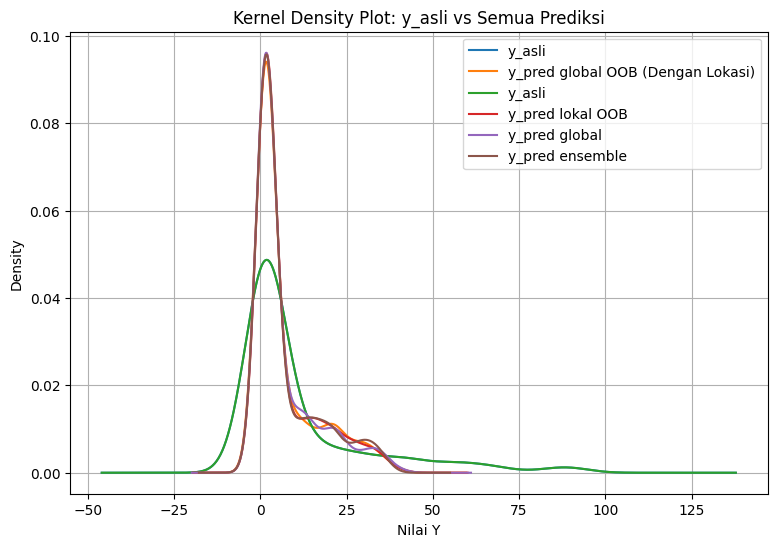

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Log_Bisquare_Juni.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_log['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

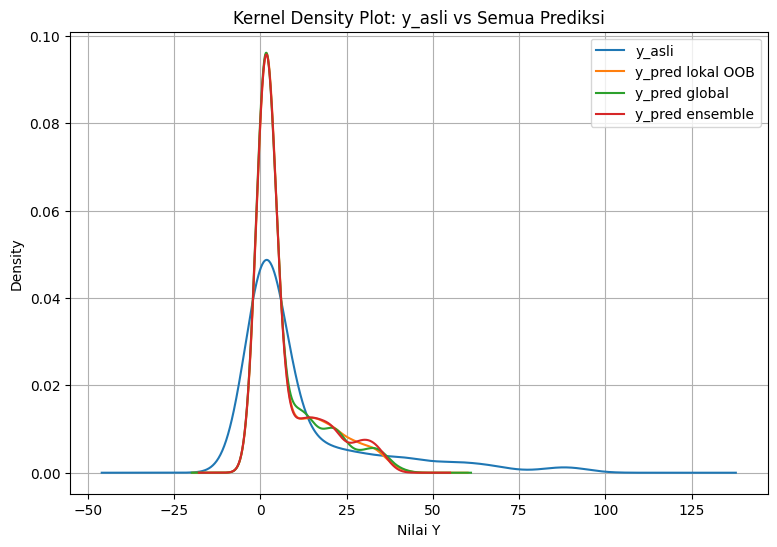

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults.to_excel(
    'LMResults_GWXGB_Log_Bisquare_Juni.xlsx',
    index=False
)

##### Pengecekan Autokorelasi Residual Spasial

In [ ]:
LMResults['Res_ensemble'] = (
    LMResults['y_asli'] - LMResults['y_ensemble']
)

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual33 = LMResults['y_asli'] - LMResults['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual33, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.2271372772076565
p-value   : 0.001
z-score   : 7.968875992328876


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual lokal OOB
residual = LMResults['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.19924873574898921
p-value   : 0.001
z-score   : 6.981565530812839


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual22 = LMResults['y_asli'] - LMResults['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual22, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.20166115564210488
p-value   : 0.001
z-score   : 7.056603052093829


##### Prediksi Titik Baru

In [ ]:
def predict_new_gwxgboost(
    X_train, y_train, Coords_train,
    X_new, Coords_new,
    BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    feat_importance='gain',
    alpha_wt=0.5,
    alpha_wt_type='varying',
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from xgboost import XGBRegressor

    # ======================================================
    # Validasi dan persiapan data
    # ======================================================
    X_train = pd.DataFrame(X_train).reset_index(drop=True).copy()
    y_train = pd.Series(np.ravel(y_train), name='y_asli').reset_index(drop=True)
    Coords_train = pd.DataFrame(Coords_train).reset_index(drop=True).copy()

    X_new = pd.DataFrame(X_new).reset_index(drop=True).copy()
    Coords_new = pd.DataFrame(Coords_new).reset_index(drop=True).copy()

    X_new.columns = X_train.columns

    if len(X_train) != len(y_train) or len(X_train) != len(Coords_train):
        raise ValueError("Panjang X_train, y_train, dan Coords_train harus sama.")

    if len(X_new) != len(Coords_new):
        raise ValueError("Panjang X_new dan Coords_new harus sama.")

    if (y_train < 0).any():
        raise ValueError("Semua nilai y_train harus >= 0 untuk transformasi log(y + 1).")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    # ======================================================
    # Persiapan alpha weight
    # ======================================================
    if alpha_wt_type == 'fixed':
        Alpha_Fixed = float(alpha_wt)

        if Alpha_Fixed < 0 or Alpha_Fixed > 1:
            raise ValueError("alpha_wt harus berada antara 0 dan 1.")

        Alpha_wtDF = None

    else:
        # Untuk varying, alpha_wt harus berisi alpha per titik training
        if isinstance(alpha_wt, dict) and 'alpha_wt' in alpha_wt:
            alpha_raw = alpha_wt['alpha_wt']

        elif isinstance(alpha_wt, pd.DataFrame):
            if 'alpha_wt' in alpha_wt.columns:
                alpha_raw = alpha_wt['alpha_wt']
            else:
                alpha_raw = alpha_wt.iloc[:, 0]

        else:
            alpha_raw = alpha_wt

        Alpha_wtDF = pd.Series(
            np.ravel(alpha_raw),
            name='alpha_wt'
        ).reset_index(drop=True)

        if len(Alpha_wtDF) != len(X_train):
            raise ValueError(
                "Untuk alpha_wt_type='varying', panjang alpha_wt harus sama "
                "dengan jumlah data training."
            )

        if ((Alpha_wtDF < 0) | (Alpha_wtDF > 1)).any():
            raise ValueError("Semua nilai alpha_wt varying harus berada antara 0 dan 1.")

        Alpha_Fixed = None

    # ======================================================
    # Transformasi y training
    # ======================================================
    y_train_log = pd.Series(np.log1p(y_train), name='y_log')

    # ======================================================
    # Parameter XGBoost
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:squarederror'
    params['random_state'] = random_state

    # ======================================================
    # Fungsi bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    # ======================================================
    # Fungsi feature importance per lokasi
    # ======================================================
    def get_feature_importance_df(model, feature_names, ids_new, importance_type='gain'):
        booster = model.get_booster()
        score = booster.get_score(importance_type=importance_type)

        importance_df = pd.DataFrame({
            'IDS_new': ids_new,
            'Feature': feature_names,
            'Importance': [score.get(f, 0.0) for f in feature_names]
        })

        total_importance = importance_df['Importance'].sum()

        if total_importance > 0:
            importance_df['Importance_Relative'] = (
                importance_df['Importance'] / total_importance
            )
        else:
            importance_df['Importance_Relative'] = 0.0

        importance_df['Rank'] = importance_df['Importance'].rank(
            ascending=False,
            method='dense'
        ).astype(int)

        importance_df = importance_df.sort_values(
            by=['IDS_new', 'Rank', 'Importance'],
            ascending=[True, True, False]
        ).reset_index(drop=True)

        return importance_df

    # ======================================================
    # Model global
    # ======================================================
    global_model = XGBRegressor(
        **params,
        importance_type=feat_importance
    )

    global_model.fit(X_train, y_train_log)

    # ======================================================
    # Distance matrix: titik baru ke titik training
    # ======================================================
    DistanceMatrix_NewTrain = pd.DataFrame(
        distance_matrix(Coords_new, Coords_train)
    )

    results = []
    local_models_new = []
    feature_importance_all = []

    print("================= Predict New Data GWXGBoost =================")

    # ======================================================
    # Loop setiap titik baru
    # ======================================================
    for i in range(len(X_new)):

        print(f"Predicting new location {i + 1} of {len(X_new)}")

        dist_i = DistanceMatrix_NewTrain.iloc[i, :].reset_index(drop=True)

        nearest_train_id = int(dist_i.idxmin())

        DataLocal = pd.concat(
            [
                X_train,
                y_train.rename('y_asli'),
                y_train_log,
                pd.Series(dist_i, name='Distance')
            ],
            axis=1
        )

        DataLocalSorted = DataLocal.sort_values(
            by='Distance'
        ).reset_index(drop=True)

        # ==================================================
        # Ambil data lokal berdasarkan bandwidth
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            if knn < 2:
                raise ValueError("BW_opt Adaptive minimal harus 2.")

            LocalData = DataLocalSorted.iloc[:knn, :].copy()
            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataLocalSorted[
                DataLocalSorted['Distance'] < bw
            ].copy()

            h = bw

        if LocalData.shape[0] < 2:
            raise ValueError(
                f"Jumlah data lokal untuk titik baru ke-{i} terlalu sedikit."
            )

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-3]
        LocalY_log = LocalData['y_log']

        LocalX.columns = X_train.columns

        # ==================================================
        # Bobot spasial
        # ==================================================
        if spatial_weights:
            SpatialWeights = calc_spatial_weights(
                LocalData['Distance'], h
            )
        else:
            SpatialWeights = None

        # ==================================================
        # Model lokal untuk titik baru
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY_log,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY_log)

        local_models_new.append(local_model)

        # ==================================================
        # Feature importance lokal untuk titik baru
        # ==================================================
        imp_i = get_feature_importance_df(
            model=local_model,
            feature_names=list(X_train.columns),
            ids_new=i,
            importance_type=feat_importance
        )

        feature_importance_all.append(imp_i)

        top_features = (
            imp_i.sort_values(
                by='Importance_Relative',
                ascending=False
            )
            .head(5)['Feature']
            .tolist()
        )

        # ==================================================
        # Prediksi lokal pada skala asli
        # ==================================================
        y_local_log = float(local_model.predict(X_new.iloc[[i]])[0])
        y_local = float(np.expm1(y_local_log))
        y_local = max(y_local, 0.0)

        # ==================================================
        # Prediksi global pada skala asli
        # ==================================================
        y_global_log = float(global_model.predict(X_new.iloc[[i]])[0])
        y_global = float(np.expm1(y_global_log))
        y_global = max(y_global, 0.0)

        # ==================================================
        # Alpha weight fixed atau varying
        # ==================================================
        if alpha_wt_type == 'fixed':
            Alpha_wt = Alpha_Fixed
            Alpha_Source = 'fixed'

        else:
            Alpha_wt = float(Alpha_wtDF.iloc[nearest_train_id])
            Alpha_Source = f'nearest_train_id_{nearest_train_id}'

        Beta_wt = 1 - Alpha_wt

        # ==================================================
        # Ensemble local + global
        # ==================================================
        y_ensemble = Alpha_wt * y_local + Beta_wt * y_global
        y_ensemble = max(float(y_ensemble), 0.0)

        results.append({
            'IDS_new': i,
            'Nearest_Train_ID': nearest_train_id,
            'Distance_to_Nearest': float(dist_i.min()),
            'Local_Pred': y_local,
            'Global_Pred': y_global,
            'alpha_wt_type': alpha_wt_type,
            'alpha_source': Alpha_Source,
            'alpha_wt': Alpha_wt,
            'beta_wt': Beta_wt,
            'Ensemble_Pred': y_ensemble,
            'Top_Features': ', '.join(top_features)
        })

    Prediction_New = pd.DataFrame(results)

    Feature_Importance_New = pd.concat(
        feature_importance_all,
        ignore_index=True
    )

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        Prediction_New.to_csv(
            os.path.join(path_save, 'Prediction_New_GWXGBoost.csv'),
            index=False
        )

        Feature_Importance_New.to_csv(
            os.path.join(path_save, 'Feature_Importance_New_GWXGBoost.csv'),
            index=False
        )

    output = {
        'Prediction_New': Prediction_New,
        'Feature_Importance_New': Feature_Importance_New,
        'local_models_new': local_models_new,
        'global_model': global_model
    }

    return output

In [ ]:
# 1) Baca Excel (sheet pertama)
prediksi = pd.read_excel("/content/data_prediksi_jun-agus.xlsx")
prediksi.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         173 non-null    int64  
 1   left       173 non-null    float64
 2   top        173 non-null    float64
 3   right      173 non-null    float64
 4   bottom     173 non-null    float64
 5   row_index  173 non-null    int64  
 6   col_index  173 non-null    int64  
 7   Longitude  173 non-null    float64
 8   Latitude   173 non-null    float64
 9   periode    173 non-null    object 
 10  so         173 non-null    float64
 11  thetao     173 non-null    float64
 12  zos        173 non-null    float64
 13  uo         173 non-null    float64
 14  vo         173 non-null    float64
 15  chl        173 non-null    float64
 16  o2         173 non-null    float64
 17  mlotst     173 non-null    float64
 18  nppv       173 non-null    float64
dtypes: float64(15), int64(3), object(1)
memory usage: 

In [ ]:
Coords_baru = prediksi[['Longitude', 'Latitude']]
X_baru = prediksi[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
VarNames = X.columns[:]

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_baru = predict_new_gwxgboost(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=84,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    alpha_wt=output_model['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost =================
Predicting new location 1 of 173
Predicting new location 2 of 173
Predicting new location 3 of 173
Predicting new location 4 of 173
Predicting new location 5 of 173
Predicting new location 6 of 173
Predicting new location 7 of 173
Predicting new location 8 of 173
Predicting new location 9 of 173
Predicting new location 10 of 173
Predicting new location 11 of 173
Predicting new location 12 of 173
Predicting new location 13 of 173
Predicting new location 14 of 173
Predicting new location 15 of 173
Predicting new location 16 of 173
Predicting new location 17 of 173
Predicting new location 18 of 173
Predicting new location 19 of 173
Predicting new location 20 of 173
Predicting new location 21 of 173
Predicting new location 22 of 173
Predicting new location 23 of 173
Predicting new location 24 of 173
Predicting new location 25 of 173
Predicting new location 26 of 173
Predicting new location 27 of 173
Predicting new location 28 o

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_baru['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,193,0.500000,0.478754,0.770061,varying,nearest_train_id_193,1.0,0.0,0.478754,"zos, uo, thetao, mlotst, vo"
1,1,193,0.707107,0.502726,0.592652,varying,nearest_train_id_193,1.0,0.0,0.502726,"zos, mlotst, uo, so, thetao"
2,2,197,0.500000,0.621124,0.648605,varying,nearest_train_id_197,0.5,0.5,0.634865,"zos, uo, thetao, mlotst, vo"
3,3,201,0.500000,0.800194,0.965900,varying,nearest_train_id_201,1.0,0.0,0.800194,"zos, mlotst, thetao, uo, vo"
4,4,205,0.500000,0.985612,0.901170,varying,nearest_train_id_205,0.5,0.5,0.943391,"thetao, zos, nppv, vo, uo"
...,...,...,...,...,...,...,...,...,...,...,...
168,168,178,0.500000,0.805205,0.966771,varying,nearest_train_id_178,1.0,0.0,0.805205,"so, thetao, zos, uo, vo"
169,169,183,0.500000,0.843192,0.738470,varying,nearest_train_id_183,0.5,0.5,0.790831,"zos, uo, so, thetao, vo"
170,170,187,0.707107,0.873475,1.217584,varying,nearest_train_id_187,0.5,0.5,1.045529,"uo, zos, so, thetao, vo"
171,171,187,0.500000,1.033227,1.235490,varying,nearest_train_id_187,0.5,0.5,1.134359,"uo, zos, chl, so, nppv"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_baru['Feature_Importance_New']

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local'] = hasil_prediksi_baru['Prediction_New']['Local_Pred']
prediksi['Pred_Global'] = hasil_prediksi_baru['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble'] = hasil_prediksi_baru['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_baru.xlsx',
    index=False
)

In [ ]:
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Bisquare_Juni.xlsx',
    index=False
)

#### Adaptive Gaussian

In [ ]:
output_model2 = build_local_gwxgboost(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=50,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_gwxgb_log_squarederror'
)

================= Building Local GWXGBoost Log-Squarederror =================
Calculating local model 1 of 437
Calculating local model 2 of 437
Calculating local model 3 of 437
Calculating local model 4 of 437
Calculating local model 5 of 437
Calculating local model 6 of 437
Calculating local model 7 of 437
Calculating local model 8 of 437
Calculating local model 9 of 437
Calculating local model 10 of 437
Calculating local model 11 of 437
Calculating local model 12 of 437
Calculating local model 13 of 437
Calculating local model 14 of 437
Calculating local model 15 of 437
Calculating local model 16 of 437
Calculating local model 17 of 437
Calculating local model 18 of 437
Calculating local model 19 of 437
Calculating local model 20 of 437
Calculating local model 21 of 437
Calculating local model 22 of 437
Calculating local model 23 of 437
Calculating local model 24 of 437
Calculating local model 25 of 437
Calculating local model 26 of 437
Calculating local model 27 of 437
Calculating l

In [ ]:
LMResults2 = output_model2['Prediction']
Evaluation_Results2 = output_model2['Evaluation']

LMResults2.head(450)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,0.160920,10.719612,43.639017,-43.478097,-0.162769,21.534499,27.042383,0.5,32.227098,...,thetao,0.032818,0.196883,0.073633,0.046458,0.125154,0.145787,0.177859,0.076093,0.125316
1,1,59.519735,40.281793,30.812169,28.707566,-0.361502,22.065842,28.632910,1.0,15.650963,...,nppv,0.069688,0.150187,0.114407,0.111253,0.078048,0.110376,0.122297,0.085182,0.158561
2,2,22.800757,37.903665,42.119379,-19.318622,-0.223532,21.872259,28.183484,0.5,15.030425,...,nppv,0.046142,0.154528,0.121242,0.081470,0.050821,0.147783,0.116266,0.073866,0.207882
3,3,15.638379,20.560558,19.105267,-3.466888,-0.332336,19.700422,24.987516,1.0,23.261343,...,o2,0.098843,0.000000,0.147132,0.073006,0.074196,0.166331,0.239693,0.081182,0.119617
4,4,36.777131,24.130793,16.397966,20.379165,-0.384023,22.810773,28.940059,1.0,13.075637,...,o2,0.058190,0.142714,0.108943,0.121951,0.076912,0.144325,0.181440,0.073785,0.091740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,432,11.311936,2.799521,1.821952,9.489984,-0.127832,2.418561,4.747064,0.5,2.161037,...,zos,0.063103,0.093884,0.167241,0.069489,0.110645,0.163915,0.105467,0.078275,0.147981
433,433,18.308996,3.496027,1.956398,16.352598,-0.077242,2.227882,4.280013,0.5,2.110199,...,zos,0.127302,0.066644,0.173051,0.074933,0.103749,0.098515,0.114581,0.093865,0.147359
434,434,0.368463,1.534359,2.153922,-1.785459,-0.074786,2.560472,5.240315,0.5,1.661436,...,nppv,0.090085,0.129462,0.099150,0.072591,0.104479,0.140944,0.120717,0.092349,0.150222
435,435,0.331866,1.715188,2.035701,-1.703835,-0.083953,2.619473,5.138317,0.5,0.894783,...,thetao,0.099611,0.154926,0.084606,0.084994,0.135709,0.107355,0.120581,0.115426,0.096792


In [ ]:
Evaluation_Results2

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Log-Squarederror - Pred,LM_yPred,0.563778,5.877116,12.812358
1,Local XGBoost Log-Squarederror - OOB,LM_yOOB,0.359909,7.658417,15.520151
2,Global XGBoost Log-Squarederror - OOB,yGhat,0.307716,7.951666,16.140509
3,Ensemble Local + Global,y_ensemble,0.395148,7.256404,15.086891


<Figure size 900x600 with 0 Axes>

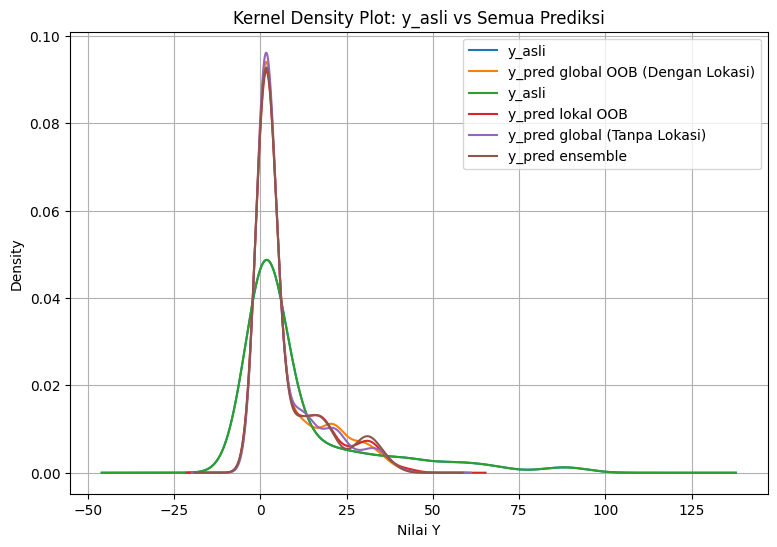

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Log_Gaussian_Juni.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_log['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

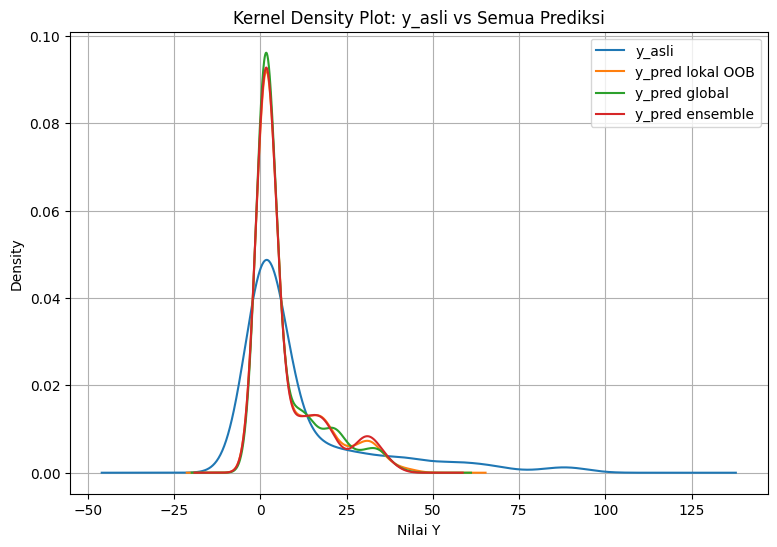

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults2['y_asli'].plot(kind='kde', label='y_asli')
LMResults2['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults2['yGhat'].plot(kind='kde', label='y_pred global')
LMResults2['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults2.to_excel(
    'LMResults_GWXGB_Log_Gaussian_Juni.xlsx',
    index=False
)

##### Pengecekan Autokorelasi

In [ ]:
LMResults2['Res_ensemble'] = (
    LMResults2['y_asli'] - LMResults2['y_ensemble']
)

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual12 = LMResults2['y_asli'] - LMResults2['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual12, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.2271372772076565
p-value   : 0.001
z-score   : 7.968875992328876


In [ ]:
## XGBoost Lokal OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual lokal OOB
residual23 = LMResults2['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual23, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.18453704035634352
p-value   : 0.001
z-score   : 6.451475697284111


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual32 = LMResults2['y_asli'] - LMResults2['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual32, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.19236973389354836
p-value   : 0.001
z-score   : 6.721156470684751


##### Prediksi Titik Baru

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_baru = predict_new_gwxgboost(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=50,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    alpha_wt=output_model2['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost =================
Predicting new location 1 of 173
Predicting new location 2 of 173
Predicting new location 3 of 173
Predicting new location 4 of 173
Predicting new location 5 of 173
Predicting new location 6 of 173
Predicting new location 7 of 173
Predicting new location 8 of 173
Predicting new location 9 of 173
Predicting new location 10 of 173
Predicting new location 11 of 173
Predicting new location 12 of 173
Predicting new location 13 of 173
Predicting new location 14 of 173
Predicting new location 15 of 173
Predicting new location 16 of 173
Predicting new location 17 of 173
Predicting new location 18 of 173
Predicting new location 19 of 173
Predicting new location 20 of 173
Predicting new location 21 of 173
Predicting new location 22 of 173
Predicting new location 23 of 173
Predicting new location 24 of 173
Predicting new location 25 of 173
Predicting new location 26 of 173
Predicting new location 27 of 173
Predicting new location 28 o

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_baru['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,193,0.500000,0.463440,0.770061,varying,nearest_train_id_193,1.0,0.0,0.463440,"zos, uo, vo, thetao, mlotst"
1,1,193,0.707107,0.429073,0.592652,varying,nearest_train_id_193,1.0,0.0,0.429073,"zos, mlotst, uo, vo, chl"
2,2,197,0.500000,0.479262,0.648605,varying,nearest_train_id_197,0.5,0.5,0.563934,"zos, thetao, uo, vo, mlotst"
3,3,201,0.500000,0.719855,0.965900,varying,nearest_train_id_201,1.0,0.0,0.719855,"zos, uo, thetao, vo, chl"
4,4,205,0.500000,0.927367,0.901170,varying,nearest_train_id_205,0.5,0.5,0.914269,"zos, thetao, nppv, uo, vo"
...,...,...,...,...,...,...,...,...,...,...,...
168,168,178,0.500000,0.774265,0.966771,varying,nearest_train_id_178,1.0,0.0,0.774265,"uo, mlotst, o2, vo, thetao"
169,169,183,0.500000,0.863971,0.738470,varying,nearest_train_id_183,0.5,0.5,0.801221,"zos, uo, nppv, so, thetao"
170,170,187,0.707107,0.857167,1.217584,varying,nearest_train_id_187,1.0,0.0,0.857167,"zos, mlotst, uo, vo, so"
171,171,187,0.500000,1.144887,1.235490,varying,nearest_train_id_187,1.0,0.0,1.144887,"nppv, uo, zos, so, chl"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_baru['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Gaussian_Juni.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_baru.xlsx',
    index=False
)

## XGBoost Lokal Tweedie

### Optimasi Bandwith

In [ ]:
def optimize_bw_gw_xgboost_tweedie(
    X, y, Coords, params,
    bw_min, bw_max, step=1,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    max_iter=30,
    tol=1e-3,
    path_save=False
):
    """
    Optimasi bandwidth GWXGBoost Tweedie:
    - Y tidak ditransformasi log
    - Model lokal menggunakan objective='reg:tweedie'
    - Pemilihan bandwidth berdasarkan CV_MAE terkecil pada skala asli
    """

    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, GridSearchCV
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error
        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # =========================================================
    # Validasi data
    # =========================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk objective Tweedie.")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    # =========================================================
    # Pastikan objective Tweedie digunakan
    # =========================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'

    if 'tweedie_variance_power' not in params:
        params['tweedie_variance_power'] = 1.5

    # =========================================================
    # Param grid sederhana
    # Bisa diperluas sesuai kebutuhan
    # =========================================================
    param_grid = {
        'reg_alpha': [params.get('reg_alpha', 0)]
    }

    # =========================================================
    # Scoring CV berdasarkan skala asli
    # =========================================================
    def scorer_neg_mae_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return -rmse_func(y_val, y_pred)

    def scorer_r2_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return r2_score(y_val, y_pred)

    scoring = {
        'neg_mean_absolute_error_original': scorer_neg_mae_original,
        'neg_root_mean_squared_error_original': scorer_neg_rmse_original,
        'r2_original': scorer_r2_original
    }

    print("================= Optimizing bandwidth =================")
    print(f"Bandwidth mode : {Kernel}")
    print(f"Kernel function: {KernelFunction}")
    print(f"Spatial weights: {spatial_weights}")
    print("Model objective: reg:tweedie")
    print(f"Tweedie variance power: {params['tweedie_variance_power']}")
    print("Selection rule : minimum CV_MAE on original scale")

    num_rows = len(X)
    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    if Kernel == 'Adaptive':
        bw_min = int(bw_min)
        bw_max = min(int(bw_max), num_rows - 1)
        step = int(step)

        if bw_min < 1:
            raise ValueError("Untuk Adaptive, bw_min minimal 1.")
        if bw_min > bw_max:
            raise ValueError("Untuk Adaptive, bw_min harus <= bw_max.")
        if step < 1:
            raise ValueError("Untuk Adaptive, step minimal 1.")

    else:
        bw_min = float(bw_min)
        bw_max = float(bw_max)

        if bw_min <= 0 or bw_max <= 0 or bw_min >= bw_max:
            raise ValueError("Untuk Fixed, pastikan 0 < bw_min < bw_max.")

    results_cache = {}

    # =========================================================
    # Bobot spasial
    # =========================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0
        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)
        else:
            raise ValueError("KernelFunction tidak dikenal.")

        return np.asarray(w, dtype=float)

    def bw_key(b):
        if Kernel == 'Adaptive':
            return int(round(b))
        else:
            return round(float(b), 10)

    # =========================================================
    # Evaluasi satu bandwidth
    # =========================================================
    def evaluate_bandwidth(b):
        if Kernel == 'Adaptive':
            b_eval = int(round(b))
            b_eval = max(int(bw_min), min(int(bw_max), b_eval))
            bw_label = f"{b_eval:d}"
        else:
            b_eval = float(b)
            if b_eval <= 0:
                return {
                    'BW': b_eval,
                    'R2_asli': np.nan,
                    'MAE_asli': np.nan,
                    'RMSE_asli': np.nan,
                    'CV_MAE': np.inf,
                    'LMResults': None,
                    'status': 'bw harus > 0'
                }
            bw_label = f"{b_eval:.6f}"

        key = bw_key(b_eval)
        if key in results_cache:
            return results_cache[key]

        listIDs = []
        yt_asli = []
        LM_yOOB_asli = []
        LM_ResOOB_asli = []

        failed_reason = None

        for i in range(num_rows):
            Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
            Neighbours.columns = ['Distance']

            Data = pd.concat([X, y, Neighbours], axis=1)
            DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

            # Titik pusat sebagai OOB
            XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-2]).T
            YcentralOOB_asli = float(DataSorted.iloc[0, -2])

            if Kernel == 'Adaptive':
                knn = int(b_eval)
                LocalData = DataSorted.iloc[1:knn + 1, :].copy()

                if LocalData.shape[0] < n_splits:
                    failed_reason = (
                        f"bw={b_eval} gagal: jumlah data lokal < n_splits "
                        f"pada lokasi ke-{i}"
                    )
                    break

                h = float(LocalData['Distance'].max())

            else:
                LocalData = DataSorted[DataSorted.Distance < b_eval].copy()
                LocalData = LocalData.iloc[1:, :]

                if LocalData.shape[0] < n_splits:
                    failed_reason = (
                        f"bw={b_eval:.6f} gagal: jumlah data lokal < n_splits "
                        f"pada lokasi ke-{i}"
                    )
                    break

                h = float(b_eval)

            h = max(h, 1e-12)

            LocalX = LocalData.iloc[:, :-2]
            LocalY = LocalData.iloc[:, -2]

            if spatial_weights:
                SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            else:
                SpatialWeights = None

            model = XGBRegressor(**params)

            kfold = KFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=7
            )

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                scoring=scoring,
                refit='neg_mean_absolute_error_original',
                return_train_score=True,
                n_jobs=-1,
                cv=kfold
            )

            try:
                if spatial_weights:
                    grid_result = grid_search.fit(
                        LocalX,
                        LocalY,
                        sample_weight=SpatialWeights
                    )
                else:
                    grid_result = grid_search.fit(LocalX, LocalY)

                best_model = grid_result.best_estimator_

                yOOB_asli = float(best_model.predict(XcentralOOB)[0])
                yOOB_asli = max(yOOB_asli, 0.0)

            except Exception as e:
                failed_reason = f"bw={bw_label} gagal pada lokasi ke-{i}: {str(e)}"
                break

            listIDs.append(i)
            yt_asli.append(YcentralOOB_asli)
            LM_yOOB_asli.append(yOOB_asli)
            LM_ResOOB_asli.append(YcentralOOB_asli - yOOB_asli)

        if failed_reason is not None:
            result = {
                'BW': b_eval,
                'R2_asli': np.nan,
                'MAE_asli': np.nan,
                'RMSE_asli': np.nan,
                'CV_MAE': np.inf,
                'LMResults': None,
                'status': failed_reason
            }

            results_cache[key] = result
            print(f"bw={bw_label}, CV_MAE=inf")
            print(f"   alasan: {failed_reason}")
            return result

        LMResults = pd.DataFrame({
            'IDS': listIDs,
            'y_asli': yt_asli,
            'LM_yOOB_asli': LM_yOOB_asli,
            'LM_ResOOB_asli': LM_ResOOB_asli
        })

        y_true_asli = LMResults['y_asli']
        y_pred_asli = LMResults['LM_yOOB_asli']

        R2_asli = r2_score(y_true_asli, y_pred_asli)
        MAE_asli = mean_absolute_error(y_true_asli, y_pred_asli)
        RMSE_asli = rmse_func(y_true_asli, y_pred_asli)

        CV_MAE = MAE_asli

        result = {
            'BW': b_eval,
            'R2_asli': R2_asli,
            'MAE_asli': MAE_asli,
            'RMSE_asli': RMSE_asli,
            'CV_MAE': CV_MAE,
            'LMResults': LMResults,
            'status': 'ok'
        }

        results_cache[key] = result

        print(
            f"bw={bw_label}, "
            f"CV_MAE={CV_MAE:.6f}, "
            f"R2={R2_asli:.6f}, "
            f"RMSE={RMSE_asli:.6f}"
        )

        return result

    # =========================================================
    # Adaptive: Grid Search
    # =========================================================
    def optimize_adaptive_grid():
        bw_candidates = list(range(int(bw_min), int(bw_max) + 1, int(step)))

        if len(bw_candidates) == 0:
            raise ValueError("Tidak ada kandidat bandwidth adaptive.")

        print("Optimization method: Grid Search (Adaptive)")

        for bw in bw_candidates:
            evaluate_bandwidth(bw)

    # =========================================================
    # Fixed: Golden Section Ratio
    # =========================================================
    def optimize_fixed_golden():
        a = float(bw_min)
        b = float(bw_max)

        phi = (1 + np.sqrt(5)) / 2
        invphi = 1 / phi

        c = b - (b - a) * invphi
        d = a + (b - a) * invphi

        fc = evaluate_bandwidth(c)['CV_MAE']
        fd = evaluate_bandwidth(d)['CV_MAE']

        iter_count = 0

        print("Optimization method: Golden Section Ratio (Fixed)")

        while abs(b - a) > tol and iter_count < max_iter:
            if fc <= fd:
                b = d
                d = c
                fd = fc
                c = b - (b - a) * invphi
                fc = evaluate_bandwidth(c)['CV_MAE']
            else:
                a = c
                c = d
                fc = fd
                d = a + (b - a) * invphi
                fd = evaluate_bandwidth(d)['CV_MAE']

            iter_count += 1
            print(f"[Golden iter {iter_count}] interval bw = [{a:.6f}, {b:.6f}]")

        mid = (a + b) / 2.0
        refine_points = np.unique([a, c, mid, d, b])

        for bw_val in refine_points:
            evaluate_bandwidth(float(bw_val))

    # =========================================================
    # Jalankan optimasi
    # =========================================================
    if Kernel == 'Adaptive':
        optimize_adaptive_grid()
    else:
        optimize_fixed_golden()

    # =========================================================
    # Rekap hasil bandwidth
    # =========================================================
    BW_results = pd.DataFrame([
        {
            'BW': v['BW'],
            'R2_asli': v['R2_asli'],
            'MAE_asli': v['MAE_asli'],
            'RMSE_asli': v['RMSE_asli'],
            'CV_MAE': v['CV_MAE'],
            'status': v['status']
        }
        for v in results_cache.values()
    ]).sort_values(by='BW').reset_index(drop=True)

    BW_results_valid = (
        BW_results
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=['CV_MAE'])
    )

    if BW_results_valid.empty:
        raise ValueError("Semua kandidat bandwidth gagal dievaluasi. Coba perbesar bandwidth.")

    idx_best = BW_results_valid['CV_MAE'].idxmin()
    BW_opt = BW_results_valid.loc[idx_best, 'BW']
    CV_MAE_min = float(BW_results_valid.loc[idx_best, 'CV_MAE'])

    if Kernel == 'Adaptive':
        BW_opt = int(round(BW_opt))
    else:
        BW_opt = float(BW_opt)

    best_result = evaluate_bandwidth(BW_opt)
    best_LMResults = best_result['LMResults']

    print("=========================================================================")

    if Kernel == 'Adaptive':
        print(f"Best bandwidth        : {BW_opt}")
    else:
        print(f"Best bandwidth        : {BW_opt:.6f}")

    print(f"Best CV_MAE           : {CV_MAE_min:.6f}")
    print(f"R2 terbaik            : {best_result['R2_asli']:.6f}")
    print(f"MAE terbaik           : {best_result['MAE_asli']:.6f}")
    print(f"RMSE terbaik          : {best_result['RMSE_asli']:.6f}")
    print("=========================================================================")

    # =========================================================
    # Simpan hasil
    # =========================================================
    if not path_save:
        bw_path = 'BW_results_tweedie.csv'
        lm_path = 'LMResults_best_bw_tweedie.csv'
    else:
        os.makedirs(path_save, exist_ok=True)
        bw_path = os.path.join(path_save, 'BW_results_tweedie.csv')
        lm_path = os.path.join(path_save, 'LMResults_best_bw_tweedie.csv')

    BW_results.to_csv(bw_path, index=False)

    if best_LMResults is not None:
        best_LMResults.to_csv(lm_path, index=False)

    return BW_opt, BW_results, best_LMResults

In [ ]:
Coords = data[['Longitude', 'Latitude']]

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
xgb_params2 = {
    "objective": "reg:tweedie",
    'tweedie_variance_power': 1.7459610067040099,
    "n_estimators": 100,
    "learning_rate": 0.05,
    "max_depth": 2,
    "subsample": 0.7,
    "colsample_bytree": 0.8,
    'gamma': 1,
    'reg_alpha': 0.5,
    'reg_lambda': 1,
    'min_child_weight': 5,
     "random_state": 42
}

#### Adaptive Bisquare

In [ ]:
BW_opt3, BW_results3, best_LMResults3 = optimize_bw_gw_xgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params2,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Bisquare
Spatial weights: True
Model objective: reg:tweedie
Tweedie variance power: 1.7459610067040099
Selection rule : minimum CV_MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=7.503583, R2=0.448014, RMSE=14.412496
bw=52, CV_MAE=7.486917, R2=0.447000, RMSE=14.425730
bw=54, CV_MAE=7.499264, R2=0.447563, RMSE=14.418379
bw=56, CV_MAE=7.526250, R2=0.450075, RMSE=14.385559
bw=58, CV_MAE=7.517608, R2=0.449601, RMSE=14.391762
bw=60, CV_MAE=7.492847, R2=0.449303, RMSE=14.395660
bw=62, CV_MAE=7.542687, R2=0.446351, RMSE=14.434189
bw=64, CV_MAE=7.544993, R2=0.444322, RMSE=14.460614
bw=66, CV_MAE=7.539318, R2=0.443778, RMSE=14.467689
bw=68, CV_MAE=7.550203, R2=0.443534, RMSE=14.470861
bw=70, CV_MAE=7.541830, R2=0.447126, RMSE=14.424079
bw=72, CV_MAE=7.521814, R2=0.450050, RMSE=14.385887
bw=74, CV_MAE=7.524645, R2=0.447561, RMSE=14.418408
bw=76, CV_MAE=7.581588, R2=

#### Adaptive Gaussian

In [ ]:
BW_opt4, BW_results4, best_LMResults4 = optimize_bw_gw_xgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params2,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Gaussian
Spatial weights: True
Model objective: reg:tweedie
Tweedie variance power: 1.7459610067040099
Selection rule : minimum CV_MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=7.591751, R2=0.442984, RMSE=14.478018
bw=52, CV_MAE=7.550994, R2=0.443855, RMSE=14.466693
bw=54, CV_MAE=7.650667, R2=0.426360, RMSE=14.692475
bw=56, CV_MAE=7.625695, R2=0.433296, RMSE=14.603377
bw=58, CV_MAE=7.693237, R2=0.426621, RMSE=14.689125
bw=60, CV_MAE=7.712012, R2=0.428837, RMSE=14.660711
bw=62, CV_MAE=7.733021, R2=0.428505, RMSE=14.664972
bw=64, CV_MAE=7.670437, R2=0.425326, RMSE=14.705706
bw=66, CV_MAE=7.710153, R2=0.426587, RMSE=14.689564
bw=68, CV_MAE=7.632488, R2=0.439373, RMSE=14.524872
bw=70, CV_MAE=7.750829, R2=0.422265, RMSE=14.744823
bw=72, CV_MAE=7.710045, R2=0.429151, RMSE=14.656688
bw=74, CV_MAE=7.669784, R2=0.431303, RMSE=14.629037
bw=76, CV_MAE=7.549134, R2=

### Pemodelan XGBoost Lokal

In [ ]:
def build_local_gwxgboost_tweedie(
    X, y, Coords, BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd

    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, cross_validate
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error

        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)

    except ImportError:

        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # ======================================================
    # Validasi data
    # ======================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk objective Tweedie.")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    if alpha_wt < 0 or alpha_wt > 1:
        raise ValueError("alpha_wt harus berada antara 0 dan 1.")

    # ======================================================
    # Parameter Tweedie
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'

    if 'tweedie_variance_power' not in params:
        params['tweedie_variance_power'] = 1.5

    params['random_state'] = random_state

    num_rows = len(X)
    feature_names = list(X.columns)

    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    # ======================================================
    # Model global penuh untuk peubah penting global
    # Berdasarkan nilai gain
    # ======================================================
    global_model_full = XGBRegressor(
        **params,
        importance_type='gain'
    )

    global_model_full.fit(X, y)

    # Ambil nilai gain dari booster
    global_gain_dict = global_model_full.get_booster().get_score(
        importance_type='gain'
    )

    # Susun semua peubah agar tetap muncul,
    # termasuk peubah yang tidak pernah dipakai split
    GlobalImportance = pd.DataFrame({
        'Feature': feature_names,
        'Gain': [
            float(global_gain_dict.get(feature, 0.0))
            for feature in feature_names
        ]
    })

    # Normalisasi gain agar lebih mudah dibaca sebagai proporsi
    total_gain = GlobalImportance['Gain'].sum()

    if total_gain > 0:
        GlobalImportance['Gain_Normalized'] = (
            GlobalImportance['Gain'] / total_gain
        )
    else:
        GlobalImportance['Gain_Normalized'] = 0.0

    GlobalImportance = GlobalImportance.sort_values(
        by='Gain',
        ascending=False
    ).reset_index(drop=True)

    # ======================================================
    # Scoring CV lokal
    # ======================================================
    def scorer_neg_mae(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)
        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)
        return -rmse_func(y_val, y_pred)

    scoring = {
        'neg_mae': scorer_neg_mae,
        'neg_rmse': scorer_neg_rmse,
        'r2': 'r2'
    }

    # ======================================================
    # Bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    results = []
    importance_rows = []
    bestLocalModel = []

    print("================= Building Local GWXGBoost Tweedie =================")
    print("================= Global importance by gain has been calculated =================")

    # ======================================================
    # Loop model lokal
    # ======================================================
    for i in range(num_rows):

        print(f"Calculating local model {i + 1} of {num_rows}")

        Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
        Neighbours.columns = ['Distance']

        Data = pd.concat([X, y, Neighbours], axis=1)
        DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

        XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-2]).T
        XcentralOOB.columns = X.columns

        YcentralOOB = float(DataSorted.iloc[0, -2])

        # ==================================================
        # Local data OOB dan full
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            LocalData = DataSorted.iloc[1:knn + 1, :].copy()
            LocalDataFull = DataSorted.iloc[:knn + 1, :].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataSorted[DataSorted.Distance < bw].copy()
            LocalData = LocalData.iloc[1:, :].copy()

            LocalDataFull = DataSorted[DataSorted.Distance < bw].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = bw

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-2]
        LocalY = LocalData.iloc[:, -2]

        LocalXFull = LocalDataFull.iloc[:, :-2]
        LocalYFull = LocalDataFull.iloc[:, -2]

        LocalX.columns = X.columns
        LocalXFull.columns = X.columns

        if spatial_weights:
            SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            SpatialWeightsFull = calc_spatial_weights(LocalDataFull['Distance'], h)
        else:
            SpatialWeights = None
            SpatialWeightsFull = None

        # ==================================================
        # Model lokal OOB
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY)

        bestLocalModel.append(local_model)

        LM_yOOB = float(local_model.predict(XcentralOOB)[0])
        LM_yOOB = max(LM_yOOB, 0.0)

        LM_ResOOB = YcentralOOB - LM_yOOB

        # ==================================================
        # CV lokal MAE, RMSE, R2
        # ==================================================
        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        try:
            if spatial_weights:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    params={'sample_weight': SpatialWeights},
                    n_jobs=-1
                )
            else:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        except TypeError:
            try:
                if spatial_weights:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY,
                        scoring=scoring,
                        cv=kfold,
                        fit_params={'sample_weight': SpatialWeights},
                        n_jobs=-1
                    )
                else:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY,
                        scoring=scoring,
                        cv=kfold,
                        n_jobs=-1
                    )

            except TypeError:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        LM_Best_score_MAE = -np.mean(cv_result['test_neg_mae'])
        LM_Best_score_RMSE = -np.mean(cv_result['test_neg_rmse'])
        LMRsqr = np.mean(cv_result['test_r2'])

        # ==================================================
        # Model lokal full: including central point
        # ==================================================
        local_model_full = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model_full.fit(
                LocalXFull,
                LocalYFull,
                sample_weight=SpatialWeightsFull
            )
        else:
            local_model_full.fit(LocalXFull, LocalYFull)

        LM_yPred = float(local_model_full.predict(XcentralOOB)[0])
        LM_yPred = max(LM_yPred, 0.0)

        # ==================================================
        # Model global excluding central point
        # Global OOB prediction
        # ==================================================
        X_global = X.drop(index=i).reset_index(drop=True)
        y_global = y.drop(index=i).reset_index(drop=True)

        global_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        global_model.fit(X_global, y_global)

        yGhat = float(global_model.predict(X.iloc[[i]])[0])
        yGhat = max(yGhat, 0.0)

        # ==================================================
        # Alpha ensemble mengikuti konsep GeoXGBoost
        # ==================================================
        res_local = YcentralOOB - LM_yOOB
        res_global = YcentralOOB - yGhat

        if alpha_wt_type == 'fixed':
            Alpha_wt = float(alpha_wt)

        elif alpha_wt_type == 'varying':
            if alpha_wt == 1:
                Alpha_wt = 1.0
            else:
                if abs(res_global) > abs(res_local):
                    Alpha_wt = 1.0
                else:
                    Alpha_wt = float(alpha_wt)

        beta_wt = 1 - Alpha_wt

        y_ensemble = Alpha_wt * LM_yOOB + beta_wt * yGhat
        y_ensemble = max(float(y_ensemble), 0.0)

        # ==================================================
        # Feature importance lokal
        # ==================================================
        Imp_ = local_model.feature_importances_

        imp_dict = {
            f'Imp_{feature_names[j]}': float(Imp_[j])
            for j in range(len(feature_names))
        }

        MaxImportance = float(np.max(Imp_))
        MaxFeatureID = feature_names[int(np.argmax(Imp_))]

        importance_rows.append({
            'IDS': i,
            **imp_dict
        })

        results.append({
            'IDS': i,
            'y_asli': YcentralOOB,

            'LM_yPred': LM_yPred,
            'LM_yOOB': LM_yOOB,
            'LM_ResOOB': LM_ResOOB,

            'LMRsqr': LMRsqr,
            'LM_Best_score_MAE': LM_Best_score_MAE,
            'LM_Best_score_RMSE': LM_Best_score_RMSE,

            'alpha_wt': Alpha_wt,
            'yGhat': yGhat,
            'y_ensemble': y_ensemble,

            'MaxImportance': MaxImportance,
            'MaxFeatureID': MaxFeatureID
        })

    # ======================================================
    # Gabungkan hasil lokal
    # ======================================================
    LMResults = pd.DataFrame(results)
    LocalImportance = pd.DataFrame(importance_rows)

    LMResults = LMResults.merge(
        LocalImportance,
        on='IDS',
        how='left'
    )

    # ======================================================
    # Ringkasan peubah penting lokal
    # ======================================================
    local_imp_cols = [
        col for col in LMResults.columns
        if col.startswith('Imp_')
    ]

    LocalImportanceSummary = []

    for col in local_imp_cols:
        feature = col.replace('Imp_', '')

        LocalImportanceSummary.append({
            'Feature': feature,
            'Mean_Local_Importance': LMResults[col].mean(),
            'Median_Local_Importance': LMResults[col].median(),
            'Std_Local_Importance': LMResults[col].std(),
            'Min_Local_Importance': LMResults[col].min(),
            'Max_Local_Importance': LMResults[col].max(),
            'Frequency_As_MaxFeature': (LMResults['MaxFeatureID'] == feature).sum(),
            'Proportion_As_MaxFeature': (
                (LMResults['MaxFeatureID'] == feature).sum() / len(LMResults)
            )
        })

    LocalImportanceSummary = pd.DataFrame(LocalImportanceSummary)

    LocalImportanceSummary = LocalImportanceSummary.sort_values(
        by='Mean_Local_Importance',
        ascending=False
    ).reset_index(drop=True)

    # ======================================================
    # Evaluasi keseluruhan data
    # ======================================================
    y_true = LMResults['y_asli']

    Evaluation_Results = pd.DataFrame({
        'Model': [
            'Local XGBoost Tweedie - Pred',
            'Local XGBoost Tweedie - OOB',
            'Global XGBoost Tweedie - OOB',
            'Ensemble Local + Global'
        ],
        'Kolom_Prediksi': [
            'LM_yPred',
            'LM_yOOB',
            'yGhat',
            'y_ensemble'
        ],
        'R2': [
            r2_score(y_true, LMResults['LM_yPred']),
            r2_score(y_true, LMResults['LM_yOOB']),
            r2_score(y_true, LMResults['yGhat']),
            r2_score(y_true, LMResults['y_ensemble'])
        ],
        'MAE': [
            mean_absolute_error(y_true, LMResults['LM_yPred']),
            mean_absolute_error(y_true, LMResults['LM_yOOB']),
            mean_absolute_error(y_true, LMResults['yGhat']),
            mean_absolute_error(y_true, LMResults['y_ensemble'])
        ],
        'RMSE': [
            rmse_func(y_true, LMResults['LM_yPred']),
            rmse_func(y_true, LMResults['LM_yOOB']),
            rmse_func(y_true, LMResults['yGhat']),
            rmse_func(y_true, LMResults['y_ensemble'])
        ]
    })

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        LMResults.to_csv(
            os.path.join(path_save, 'LocalModelResults_GWXGB_Tweedie.csv'),
            index=False
        )

        Evaluation_Results.to_csv(
            os.path.join(path_save, 'Evaluation_GWXGB_Tweedie.csv'),
            index=False
        )

        GlobalImportance.to_csv(
            os.path.join(path_save, 'GlobalImportance_GWXGB_Tweedie_Gain.csv'),
            index=False
        )

        LocalImportanceSummary.to_csv(
            os.path.join(path_save, 'LocalImportanceSummary_GWXGB_Tweedie.csv'),
            index=False
        )

    output = {
        'Prediction': LMResults,
        'Evaluation': Evaluation_Results,
        'GlobalImportance': GlobalImportance,
        'LocalImportanceSummary': LocalImportanceSummary,
        'bestLocalModel': bestLocalModel,
        'globalModelFull': global_model_full,
        'alpha_wt': LMResults['alpha_wt'].tolist()
    }

    return output

#### Adaptive Bisquare

In [ ]:
output_model3 = build_local_gwxgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=52,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_model_lokal'
)

================= Building Local GWXGBoost Tweedie =================
================= Global importance by gain has been calculated =================
Calculating local model 1 of 437
Calculating local model 2 of 437
Calculating local model 3 of 437
Calculating local model 4 of 437
Calculating local model 5 of 437
Calculating local model 6 of 437
Calculating local model 7 of 437
Calculating local model 8 of 437
Calculating local model 9 of 437
Calculating local model 10 of 437
Calculating local model 11 of 437
Calculating local model 12 of 437
Calculating local model 13 of 437
Calculating local model 14 of 437
Calculating local model 15 of 437
Calculating local model 16 of 437
Calculating local model 17 of 437
Calculating local model 18 of 437
Calculating local model 19 of 437
Calculating local model 20 of 437
Calculating local model 21 of 437
Calculating local model 22 of 437
Calculating local model 23 of 437
Calculating local model 24 of 437
Calculating local model 25 of 437
Calculat

In [ ]:
LMResults3 = output_model3['Prediction']
Evaluation_Results3 = output_model3['Evaluation']

LMResults3.head(450)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,0.160920,8.596819,45.199444,-45.038524,0.089800,17.984251,23.463599,0.5,25.976534,...,o2,0.062889,0.145422,0.092379,0.070702,0.126013,0.144612,0.149841,0.074465,0.133677
1,1,59.519735,46.849697,35.161190,24.358545,-0.177833,21.546233,27.224907,1.0,25.358858,...,zos,0.118876,0.095239,0.176947,0.080791,0.053125,0.083041,0.143307,0.083681,0.164993
2,2,22.800757,39.560719,54.925205,-32.124448,-0.188081,20.837850,25.951279,0.5,26.438425,...,thetao,0.056078,0.185201,0.148646,0.058735,0.049228,0.138659,0.090035,0.125559,0.147858
3,3,15.638379,22.331028,41.434059,-25.795680,-0.100315,18.510917,23.428529,0.5,29.249670,...,nppv,0.071537,0.110273,0.100987,0.098019,0.141264,0.068858,0.146720,0.109415,0.152928
4,4,36.777131,32.526131,16.082020,20.695111,-0.129587,20.106986,25.725950,0.5,27.473789,...,thetao,0.077601,0.197975,0.169289,0.075843,0.062900,0.107310,0.110629,0.071794,0.126657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,432,11.311936,6.835798,2.021055,9.290881,-4.880654,3.680851,5.586223,0.5,3.126340,...,nppv,0.127134,0.116970,0.097478,0.109590,0.088055,0.111798,0.136486,0.064001,0.148488
433,433,18.308996,11.126330,1.448227,16.860770,-1.178681,3.058288,5.297654,0.5,2.489532,...,o2,0.153846,0.091693,0.060601,0.102060,0.150174,0.085035,0.174466,0.125086,0.057039
434,434,0.368463,1.300599,3.037914,-2.669451,-0.485455,3.928244,5.982401,0.5,2.484580,...,so,0.168738,0.120122,0.081110,0.087813,0.096411,0.103927,0.121154,0.106112,0.114612
435,435,0.331866,0.936513,4.172392,-3.840526,-0.816490,3.595319,6.008638,0.5,1.254560,...,thetao,0.130652,0.147355,0.073815,0.091402,0.115787,0.097860,0.114920,0.107620,0.120589


In [ ]:
LMResults3.to_excel(
    'LMResults_GWXGB_Tweedie_Bisquare_Juni.xlsx',
    index=False
)

In [ ]:
Evaluation_Results3

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Tweedie - Pred,LM_yPred,0.923286,2.804439,5.372954
1,Local XGBoost Tweedie - OOB,LM_yOOB,0.447000,7.486917,14.425730
2,Global XGBoost Tweedie - OOB,yGhat,0.391950,8.246813,15.126718
3,Ensemble Local + Global,y_ensemble,0.532337,6.654593,13.266047


<Figure size 900x600 with 0 Axes>

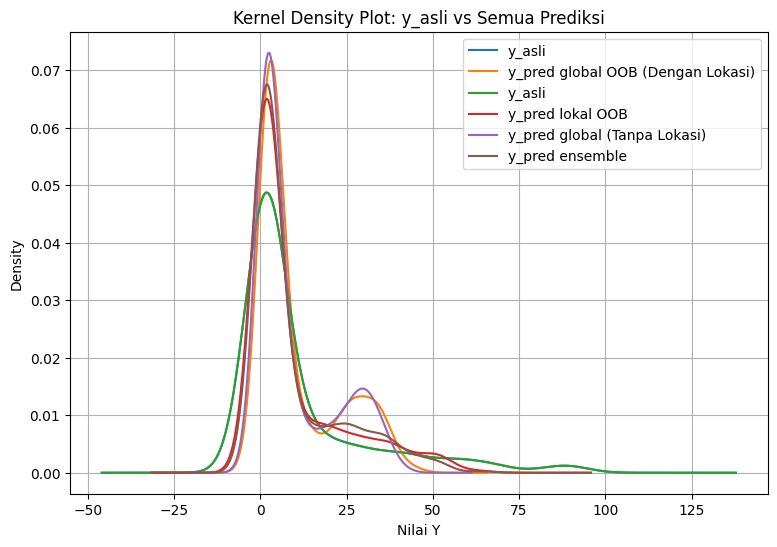

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Tweedie_Bisquare_Juni.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_tweedie['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

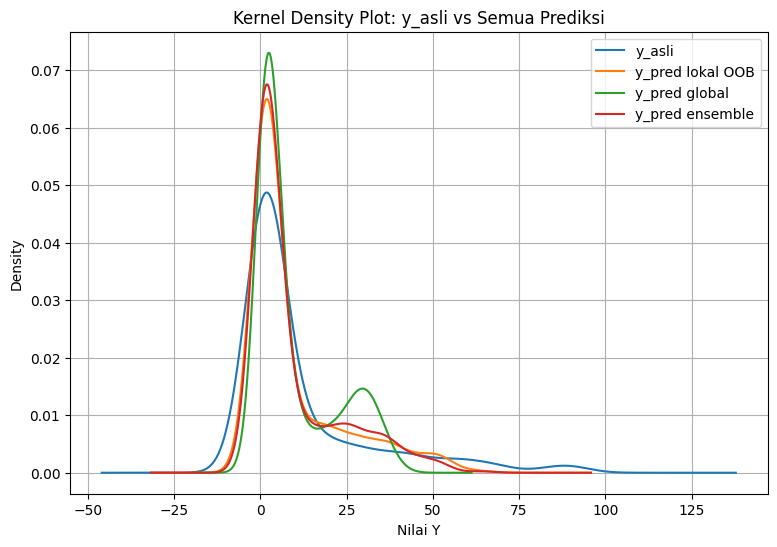

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults3['y_asli'].plot(kind='kde', label='y_asli')
LMResults3['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults3['yGhat'].plot(kind='kde', label='y_pred global')
LMResults3['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults3['Res_ensemble'] = (
    LMResults3['y_asli'] - LMResults3['y_ensemble']
)

##### Pengecekan Efek Spasial Autokorelasi Residual

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_B2 = LMResults3['y_asli'] - LMResults3['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.1888976100607747
p-value   : 0.001
z-score   : 6.5564136964778825


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual lokal OOB
residual_tweedie_B = LMResults3['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : -0.010132600279199518
p-value   : 0.369
z-score   : -0.3550204237453178


In [ ]:
## XGBoost esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_B2 = LMResults3['y_asli'] - LMResults3['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.013340130451127691
p-value   : 0.304
z-score   : 0.4973071063238706


##### Prediksi Titik Baru

In [ ]:
def predict_new_gwxgboost_tweedie(
    X_train, y_train, Coords_train,
    X_new, Coords_new,
    BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    feat_importance='gain',
    alpha_wt=0.5,
    alpha_wt_type='varying',
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from xgboost import XGBRegressor

    # ======================================================
    # Validasi dan persiapan data
    # ======================================================
    X_train = pd.DataFrame(X_train).reset_index(drop=True).copy()
    y_train = pd.Series(np.ravel(y_train), name='y_asli').reset_index(drop=True)
    Coords_train = pd.DataFrame(Coords_train).reset_index(drop=True).copy()

    X_new = pd.DataFrame(X_new).reset_index(drop=True).copy()
    Coords_new = pd.DataFrame(Coords_new).reset_index(drop=True).copy()

    X_new.columns = X_train.columns

    if len(X_train) != len(y_train) or len(X_train) != len(Coords_train):
        raise ValueError("Panjang X_train, y_train, dan Coords_train harus sama.")

    if len(X_new) != len(Coords_new):
        raise ValueError("Panjang X_new dan Coords_new harus sama.")

    if (y_train < 0).any():
        raise ValueError("Semua nilai y_train harus >= 0 untuk objective Tweedie.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    # ======================================================
    # Persiapan alpha weight
    # ======================================================
    if alpha_wt_type == 'fixed':
        Alpha_Fixed = float(alpha_wt)

        if Alpha_Fixed < 0 or Alpha_Fixed > 1:
            raise ValueError("alpha_wt harus berada antara 0 dan 1.")

        Alpha_wtDF = None

    else:
        # Untuk varying, alpha_wt harus berisi alpha per titik training
        if isinstance(alpha_wt, dict) and 'alpha_wt' in alpha_wt:
            alpha_raw = alpha_wt['alpha_wt']

        elif isinstance(alpha_wt, pd.DataFrame):
            if 'alpha_wt' in alpha_wt.columns:
                alpha_raw = alpha_wt['alpha_wt']
            else:
                alpha_raw = alpha_wt.iloc[:, 0]

        else:
            alpha_raw = alpha_wt

        Alpha_wtDF = pd.Series(
            np.ravel(alpha_raw),
            name='alpha_wt'
        ).reset_index(drop=True)

        if len(Alpha_wtDF) != len(X_train):
            raise ValueError(
                "Untuk alpha_wt_type='varying', panjang alpha_wt harus sama "
                "dengan jumlah data training."
            )

        if ((Alpha_wtDF < 0) | (Alpha_wtDF > 1)).any():
            raise ValueError("Semua nilai alpha_wt varying harus berada antara 0 dan 1.")

        Alpha_Fixed = None

    # ======================================================
    # Parameter XGBoost Tweedie
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'
    params['tweedie_variance_power'] = params.get(
        'tweedie_variance_power', 1.5
    )
    params['random_state'] = random_state

    # ======================================================
    # Fungsi bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    # ======================================================
    # Fungsi feature importance per lokasi
    # ======================================================
    def get_feature_importance_df(
        model,
        feature_names,
        ids_new,
        importance_type='gain'
    ):
        booster = model.get_booster()
        score = booster.get_score(importance_type=importance_type)

        importance_df = pd.DataFrame({
            'IDS_new': ids_new,
            'Feature': feature_names,
            'Importance': [
                score.get(feature, 0.0)
                for feature in feature_names
            ]
        })

        total_importance = importance_df['Importance'].sum()

        if total_importance > 0:
            importance_df['Importance_Relative'] = (
                importance_df['Importance'] / total_importance
            )
        else:
            importance_df['Importance_Relative'] = 0.0

        importance_df['Rank'] = importance_df['Importance'].rank(
            ascending=False,
            method='dense'
        ).astype(int)

        importance_df = importance_df.sort_values(
            by=['IDS_new', 'Rank', 'Importance'],
            ascending=[True, True, False]
        ).reset_index(drop=True)

        return importance_df

    # ======================================================
    # Model global Tweedie
    # ======================================================
    global_model = XGBRegressor(
        **params,
        importance_type=feat_importance
    )

    global_model.fit(X_train, y_train)

    # ======================================================
    # Distance matrix: titik baru ke titik training
    # ======================================================
    DistanceMatrix_NewTrain = pd.DataFrame(
        distance_matrix(Coords_new, Coords_train)
    )

    results = []
    local_models_new = []
    feature_importance_all = []

    print("================= Predict New Data GWXGBoost Tweedie =================")

    # ======================================================
    # Loop setiap titik baru
    # ======================================================
    for i in range(len(X_new)):

        print(f"Predicting new location {i + 1} of {len(X_new)}")

        dist_i = DistanceMatrix_NewTrain.iloc[i, :].reset_index(drop=True)

        nearest_train_id = int(dist_i.idxmin())

        DataLocal = pd.concat(
            [
                X_train,
                y_train.rename('y_asli'),
                pd.Series(dist_i, name='Distance')
            ],
            axis=1
        )

        DataLocalSorted = DataLocal.sort_values(
            by='Distance'
        ).reset_index(drop=True)

        # ==================================================
        # Ambil data lokal berdasarkan bandwidth
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            if knn < 2:
                raise ValueError("BW_opt Adaptive minimal harus 2.")

            LocalData = DataLocalSorted.iloc[:knn, :].copy()
            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataLocalSorted[
                DataLocalSorted['Distance'] < bw
            ].copy()

            h = bw

        if LocalData.shape[0] < 2:
            raise ValueError(
                f"Jumlah data lokal untuk titik baru ke-{i} terlalu sedikit."
            )

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-2]
        LocalY = LocalData['y_asli']

        LocalX.columns = X_train.columns

        # ==================================================
        # Bobot spasial
        # ==================================================
        if spatial_weights:
            SpatialWeights = calc_spatial_weights(
                LocalData['Distance'], h
            )
        else:
            SpatialWeights = None

        # ==================================================
        # Model lokal Tweedie untuk titik baru
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY)

        local_models_new.append(local_model)

        # ==================================================
        # Feature importance lokal per lokasi baru
        # ==================================================
        imp_i = get_feature_importance_df(
            model=local_model,
            feature_names=list(X_train.columns),
            ids_new=i,
            importance_type=feat_importance
        )

        feature_importance_all.append(imp_i)

        top_features = (
            imp_i
            .sort_values('Importance_Relative', ascending=False)
            .head(5)['Feature']
            .tolist()
        )

        # ==================================================
        # Prediksi lokal langsung skala asli Tweedie
        # ==================================================
        y_local = float(local_model.predict(X_new.iloc[[i]])[0])
        y_local = max(y_local, 0.0)

        # ==================================================
        # Prediksi global langsung skala asli Tweedie
        # ==================================================
        y_global = float(global_model.predict(X_new.iloc[[i]])[0])
        y_global = max(y_global, 0.0)

        # ==================================================
        # Alpha weight fixed atau varying
        # ==================================================
        if alpha_wt_type == 'fixed':
            Alpha_wt = Alpha_Fixed
            Alpha_Source = 'fixed'

        else:
            Alpha_wt = float(Alpha_wtDF.iloc[nearest_train_id])
            Alpha_Source = f'nearest_train_id_{nearest_train_id}'

        Beta_wt = 1 - Alpha_wt

        # ==================================================
        # Ensemble local + global
        # ==================================================
        y_ensemble = Alpha_wt * y_local + Beta_wt * y_global
        y_ensemble = max(float(y_ensemble), 0.0)

        results.append({
            'IDS_new': i,
            'Nearest_Train_ID': nearest_train_id,
            'Distance_to_Nearest': float(dist_i.min()),
            'Local_Pred': y_local,
            'Global_Pred': y_global,
            'alpha_wt_type': alpha_wt_type,
            'alpha_source': Alpha_Source,
            'alpha_wt': Alpha_wt,
            'beta_wt': Beta_wt,
            'Ensemble_Pred': y_ensemble,
            'Top_Features': ', '.join(top_features)
        })

    Prediction_New = pd.DataFrame(results)

    Feature_Importance_New = pd.concat(
        feature_importance_all,
        ignore_index=True
    )

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        Prediction_New.to_csv(
            os.path.join(path_save, 'Prediction_New_GWXGBoost_Tweedie.csv'),
            index=False
        )

        Feature_Importance_New.to_csv(
            os.path.join(path_save, 'Feature_Importance_New_GWXGBoost_Tweedie.csv'),
            index=False
        )

    output = {
        'Prediction_New': Prediction_New,
        'Feature_Importance_New': Feature_Importance_New,
        'local_models_new': local_models_new,
        'global_model': global_model
    }

    return output

In [ ]:
# 1) Baca Excel (sheet pertama)
prediksi = pd.read_excel("/content/data_prediksi_jun-agus.xlsx")
prediksi.info()
Coords_baru = prediksi[['Longitude', 'Latitude']]
X_baru = prediksi[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
VarNames = X.columns[:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         173 non-null    int64  
 1   left       173 non-null    float64
 2   top        173 non-null    float64
 3   right      173 non-null    float64
 4   bottom     173 non-null    float64
 5   row_index  173 non-null    int64  
 6   col_index  173 non-null    int64  
 7   Longitude  173 non-null    float64
 8   Latitude   173 non-null    float64
 9   periode    173 non-null    object 
 10  so         173 non-null    float64
 11  thetao     173 non-null    float64
 12  zos        173 non-null    float64
 13  uo         173 non-null    float64
 14  vo         173 non-null    float64
 15  chl        173 non-null    float64
 16  o2         173 non-null    float64
 17  mlotst     173 non-null    float64
 18  nppv       173 non-null    float64
dtypes: float64(15), int64(3), object(1)
memory usage: 

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_Tweedie_B = predict_new_gwxgboost_tweedie(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=52,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    alpha_wt=output_model3['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost Tweedie =================
Predicting new location 1 of 173
Predicting new location 2 of 173
Predicting new location 3 of 173
Predicting new location 4 of 173
Predicting new location 5 of 173
Predicting new location 6 of 173
Predicting new location 7 of 173
Predicting new location 8 of 173
Predicting new location 9 of 173
Predicting new location 10 of 173
Predicting new location 11 of 173
Predicting new location 12 of 173
Predicting new location 13 of 173
Predicting new location 14 of 173
Predicting new location 15 of 173
Predicting new location 16 of 173
Predicting new location 17 of 173
Predicting new location 18 of 173
Predicting new location 19 of 173
Predicting new location 20 of 173
Predicting new location 21 of 173
Predicting new location 22 of 173
Predicting new location 23 of 173
Predicting new location 24 of 173
Predicting new location 25 of 173
Predicting new location 26 of 173
Predicting new location 27 of 173
Predicting new locat

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_Tweedie_B['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,193,0.500000,0.294703,0.721720,varying,nearest_train_id_193,1.0,0.0,0.294703,"thetao, zos, uo, mlotst, vo"
1,1,193,0.707107,0.483944,0.705680,varying,nearest_train_id_193,1.0,0.0,0.483944,"thetao, zos, vo, uo, mlotst"
2,2,197,0.500000,1.074001,0.731565,varying,nearest_train_id_197,1.0,0.0,1.074001,"so, thetao, zos, uo, mlotst"
3,3,201,0.500000,0.545763,1.168768,varying,nearest_train_id_201,1.0,0.0,0.545763,"zos, so, thetao, vo, uo"
4,4,205,0.500000,0.635985,1.036823,varying,nearest_train_id_205,0.5,0.5,0.836404,"zos, so, mlotst, vo, nppv"
...,...,...,...,...,...,...,...,...,...,...,...
168,168,178,0.500000,0.514959,2.650437,varying,nearest_train_id_178,1.0,0.0,0.514959,"o2, vo, mlotst, uo, so"
169,169,183,0.500000,1.006341,2.702208,varying,nearest_train_id_183,0.5,0.5,1.854274,"mlotst, vo, thetao, uo, so"
170,170,187,0.707107,0.793908,2.524151,varying,nearest_train_id_187,0.5,0.5,1.659029,"mlotst, uo, vo, zos, so"
171,171,187,0.500000,2.877608,2.121384,varying,nearest_train_id_187,0.5,0.5,2.499496,"uo, mlotst, zos, vo, so"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_Tweedie_B['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Tweedie_Juni_Bisquare.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_Tweedie_B['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_Tweedie_B['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_Tweedie_B['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_Tweedie_Bisquare_Juni.xlsx',
    index=False
)

#### Adaptive Gaussian

In [ ]:
output_model4 = build_local_gwxgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=86,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_model_lokal'
)

================= Building Local GWXGBoost Tweedie =================
================= Global importance by gain has been calculated =================
Calculating local model 1 of 437
Calculating local model 2 of 437
Calculating local model 3 of 437
Calculating local model 4 of 437
Calculating local model 5 of 437
Calculating local model 6 of 437
Calculating local model 7 of 437
Calculating local model 8 of 437
Calculating local model 9 of 437
Calculating local model 10 of 437
Calculating local model 11 of 437
Calculating local model 12 of 437
Calculating local model 13 of 437
Calculating local model 14 of 437
Calculating local model 15 of 437
Calculating local model 16 of 437
Calculating local model 17 of 437
Calculating local model 18 of 437
Calculating local model 19 of 437
Calculating local model 20 of 437
Calculating local model 21 of 437
Calculating local model 22 of 437
Calculating local model 23 of 437
Calculating local model 24 of 437
Calculating local model 25 of 437
Calculat

In [ ]:
LMResults4 = output_model4['Prediction']
Evaluation_Results4 = output_model4['Evaluation']

LMResults4.head(450)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,0.160920,13.359222,35.971893,-35.810974,0.165591,17.137677,21.250097,0.5,25.976534,...,chl,0.115147,0.136978,0.126316,0.072001,0.083308,0.154665,0.124781,0.078967,0.107837
1,1,59.519735,48.636318,40.336811,19.182924,0.068681,18.437622,22.702503,1.0,25.358858,...,o2,0.081217,0.114524,0.163258,0.076903,0.080536,0.125681,0.172762,0.078472,0.106648
2,2,22.800757,36.717285,51.170334,-28.369577,0.060226,17.920959,22.534114,0.5,26.438425,...,zos,0.105100,0.141466,0.168493,0.058006,0.071718,0.144996,0.132865,0.087943,0.089413
3,3,15.638379,22.841169,36.570808,-20.932429,-0.004871,18.485310,23.550784,0.5,29.249670,...,o2,0.122767,0.087872,0.141610,0.078238,0.091058,0.130493,0.155111,0.082051,0.110801
4,4,36.777131,31.752790,31.547684,5.229447,-0.005721,18.486409,23.395767,1.0,27.473789,...,zos,0.090837,0.126891,0.171774,0.084132,0.078421,0.131454,0.139306,0.089888,0.087298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,432,11.311936,5.766239,2.003866,9.308070,-0.768455,4.627849,8.426730,0.5,3.126340,...,thetao,0.091089,0.148685,0.136989,0.112054,0.132934,0.096623,0.091181,0.114088,0.076357
433,433,18.308996,9.738356,1.696092,16.612904,0.083426,3.851067,7.870584,0.5,2.489532,...,thetao,0.084055,0.161960,0.150600,0.096975,0.107764,0.085339,0.113263,0.131256,0.068787
434,434,0.368463,0.922803,2.231147,-1.862683,-0.415796,4.281249,8.150850,1.0,2.484580,...,mlotst,0.077384,0.141113,0.103540,0.104573,0.129137,0.069109,0.088308,0.194817,0.092019
435,435,0.331866,0.930627,3.972305,-3.640438,-0.588416,4.007116,7.340857,0.5,1.254560,...,so,0.151944,0.106103,0.102556,0.096029,0.113347,0.083794,0.112702,0.148248,0.085278


In [ ]:
LMResults4.to_excel(
    'LMResults_GWXGB_Tweedie_Gaussian_Juni.xlsx',
    index=False
)

In [ ]:
Evaluation_Results4

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Tweedie - Pred,LM_yPred,0.892928,3.208204,6.347650
1,Local XGBoost Tweedie - OOB,LM_yOOB,0.428286,7.519210,14.667779
2,Global XGBoost Tweedie - OOB,yGhat,0.391950,8.246813,15.126718
3,Ensemble Local + Global,y_ensemble,0.500704,6.769266,13.707378


<Figure size 900x600 with 0 Axes>

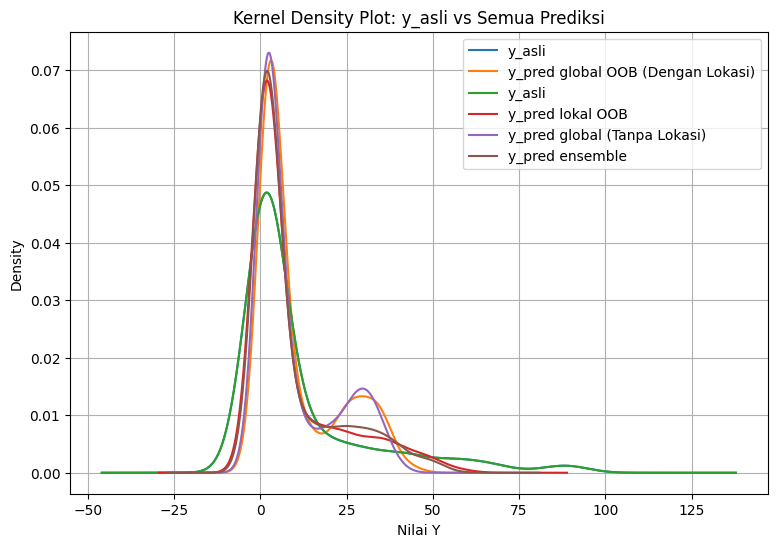

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Tweedie_Gaussian_Juni.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_tweedie['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

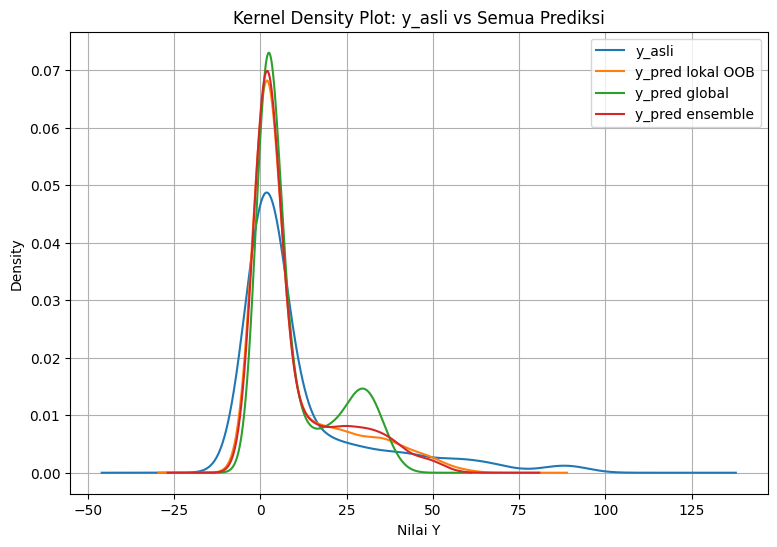

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults4['y_asli'].plot(kind='kde', label='y_asli')
LMResults4['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults4['yGhat'].plot(kind='kde', label='y_pred global')
LMResults4['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

##### Pengecekan Autokorelasi Spasial

In [ ]:
LMResults4['Res_ensemble'] = (
    LMResults4['y_asli'] - LMResults4['y_ensemble']
)

In [ ]:
## XGBoost Global
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_G2 = LMResults4['y_asli'] - LMResults4['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.1888976100607747
p-value   : 0.001
z-score   : 6.5564136964778825


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual lokal OOB
residual_tweedie_G = LMResults4['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.05698473401414681
p-value   : 0.025
z-score   : 2.1032307377228214


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_G2 = LMResults4['y_asli'] - LMResults4['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.08010303498407119
p-value   : 0.007
z-score   : 2.919200288900002


##### Prediksi Titik Baru

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_Tweedie_G = predict_new_gwxgboost_tweedie(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=86,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    alpha_wt=output_model4['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost Tweedie =================
Predicting new location 1 of 173
Predicting new location 2 of 173
Predicting new location 3 of 173
Predicting new location 4 of 173
Predicting new location 5 of 173
Predicting new location 6 of 173
Predicting new location 7 of 173
Predicting new location 8 of 173
Predicting new location 9 of 173
Predicting new location 10 of 173
Predicting new location 11 of 173
Predicting new location 12 of 173
Predicting new location 13 of 173
Predicting new location 14 of 173
Predicting new location 15 of 173
Predicting new location 16 of 173
Predicting new location 17 of 173
Predicting new location 18 of 173
Predicting new location 19 of 173
Predicting new location 20 of 173
Predicting new location 21 of 173
Predicting new location 22 of 173
Predicting new location 23 of 173
Predicting new location 24 of 173
Predicting new location 25 of 173
Predicting new location 26 of 173
Predicting new location 27 of 173
Predicting new locat

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_Tweedie_G['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,193,0.500000,0.135793,0.721720,varying,nearest_train_id_193,1.0,0.0,0.135793,"zos, thetao, uo, vo, so"
1,1,193,0.707107,0.222420,0.705680,varying,nearest_train_id_193,1.0,0.0,0.222420,"zos, vo, so, thetao, uo"
2,2,197,0.500000,0.431064,0.731565,varying,nearest_train_id_197,1.0,0.0,0.431064,"zos, so, thetao, nppv, vo"
3,3,201,0.500000,0.421989,1.168768,varying,nearest_train_id_201,1.0,0.0,0.421989,"zos, so, uo, thetao, vo"
4,4,205,0.500000,0.555272,1.036823,varying,nearest_train_id_205,0.5,0.5,0.796047,"zos, thetao, vo, so, chl"
...,...,...,...,...,...,...,...,...,...,...,...
168,168,178,0.500000,0.282741,2.650437,varying,nearest_train_id_178,1.0,0.0,0.282741,"zos, thetao, vo, uo, chl"
169,169,183,0.500000,0.380651,2.702208,varying,nearest_train_id_183,0.5,0.5,1.541430,"thetao, zos, vo, uo, chl"
170,170,187,0.707107,0.543085,2.524151,varying,nearest_train_id_187,0.5,0.5,1.533618,"thetao, vo, zos, uo, so"
171,171,187,0.500000,1.076424,2.121384,varying,nearest_train_id_187,0.5,0.5,1.598904,"thetao, zos, nppv, uo, so"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_Tweedie_G['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Tweedie_Juni_Gaussian.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_Tweedie_Gaussian_Juni.xlsx',
    index=False
)

## Visualisasi Akhir Analisis


### Hasil Prediksi

In [ ]:
# 1) Baca Excel (sheet pertama)
visual2 = pd.read_excel("/content/Visualisasi Hasil.xlsx")
visual2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Longitude           610 non-null    float64
 1   Latitude            610 non-null    float64
 2   Pred_Local          610 non-null    float64
 3   Pred_Global         610 non-null    float64
 4   Pred_Ensemble       610 non-null    float64
 5   Max_Fitur_Bisquare  610 non-null    object 
dtypes: float64(5), object(1)
memory usage: 28.7+ KB


In [ ]:
visual_jun = pd.merge(
    WPP,
    visual2[['Longitude', 'Latitude', 'Pred_Local']],
    on=['Longitude', 'Latitude'],
    how='left'
)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


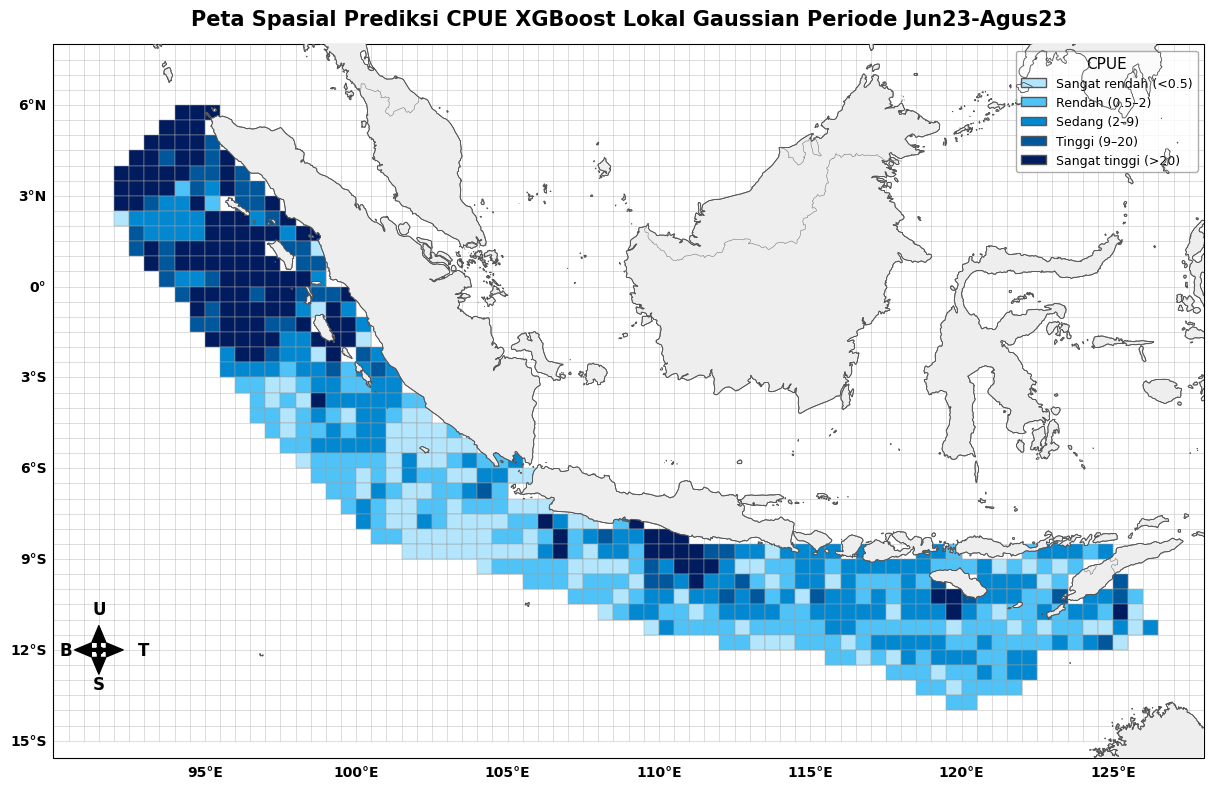

In [ ]:
import matplotlib.colors as mcolors
value_col = 'Pred_Local'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual_jun.copy()
plot_data[value_col] = pd.to_numeric(plot_data[value_col], errors='coerce')
plot_data['cpue_plot'] = plot_data[value_col].where(plot_data[value_col] > 0)

# Kategori CPUE
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

# Warna biru kontras
colors_cpue = [
    '#B3E5FC',
    '#4FC3F7',
    '#0288D1',
    '#01579B',
    '#001B5E'
]

cmap = mcolors.ListedColormap(colors_cpue)
norm = mcolors.BoundaryNorm(bins, cmap.N)

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.set_facecolor('#ffffff')

# Grid diperjelas
for lon in np.arange(lon_min, lon_max + grid_size, grid_size):
    ax.plot([lon, lon], [lat_min, lat_max],
            color='#bdbdbd', linewidth=0.45, alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=1)

for lat in np.arange(lat_min, lat_max + grid_size, grid_size):
    ax.plot([lon_min, lon_max], [lat, lat],
            color='#bdbdbd', linewidth=0.45, alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=1)

# Plot grid CPUE
for _, row in plot_data.iterrows():
    lon = row['Longitude']
    lat = row['Latitude']
    val = row['cpue_plot']

    if pd.isna(val):
        continue

    if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max):
        continue

    val = min(val, 100)

    rect = patches.Rectangle(
        (lon - grid_size/2, lat - grid_size/2),
        grid_size,
        grid_size,
        facecolor=cmap(norm(val)),
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.add_patch(rect)

# Daratan abu-abu samar
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(land, linewidth=0.6, zorder=5)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
               linewidth=0.6, edgecolor='#555555', zorder=6)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),
               linewidth=0.4, edgecolor='#777777', zorder=6)

# Label koordinat
gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Legend
legend_patches = [
    patches.Patch(facecolor=colors_cpue[i],
                  edgecolor='#555555',
                  label=labels[i])
    for i in range(len(labels))
]

ax.legend(handles=legend_patches,
          title='CPUE',
          loc='upper right',
          frameon=True,
          edgecolor='#999999',
          fontsize=9,
          title_fontsize=11)

# Mata angin lengkap
x_c, y_c = 91.5, -12
panjang = 0.8

# titik pusat
ax.scatter(x_c, y_c, color='black', s=25, transform=ccrs.PlateCarree(), zorder=10)

# U
ax.annotate('', xy=(x_c, y_c+panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c+panjang+0.4, 'U', ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# S
ax.annotate('', xy=(x_c, y_c-panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c-panjang-0.5, 'S', ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# T
ax.annotate('', xy=(x_c+panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c+panjang+0.5, y_c, 'T', va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# B
ax.annotate('', xy=(x_c-panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c-panjang-0.5, y_c, 'B', va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

ax.set_title('Peta Spasial Prediksi CPUE XGBoost Lokal Gaussian Periode Jun23-Agus23',
             fontsize=15, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()

In [ ]:
visual_jun2 = pd.merge(
    WPP,
    visual2[['Longitude', 'Latitude', 'Pred_Ensemble']],
    on=['Longitude', 'Latitude'],
    how='left'
)

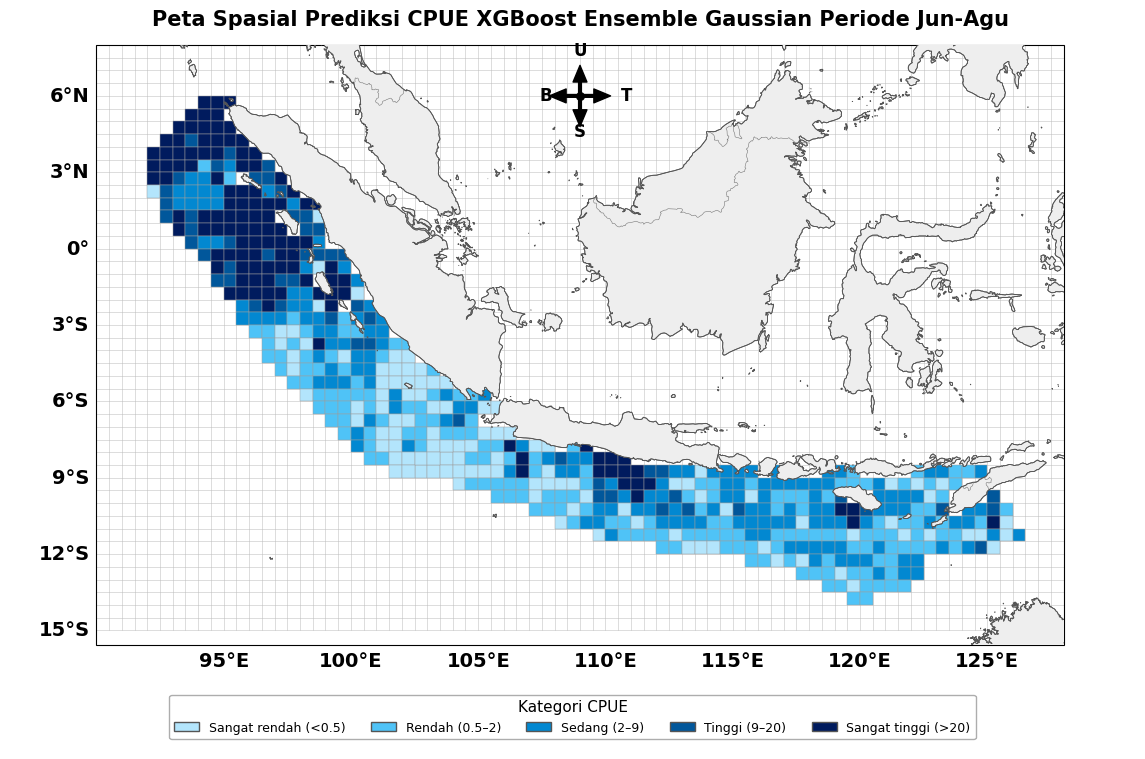

In [ ]:
import matplotlib.colors as mcolors

# =========================
# 1. PARAMETER
# =========================
value_col = 'Pred_Ensemble'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual_jun2.copy()

plot_data[value_col] = pd.to_numeric(
    plot_data[value_col],
    errors='coerce'
)

plot_data['cpue_plot'] = (
    plot_data[value_col]
    .where(plot_data[value_col] > 0)
)

# =========================
# 2. KATEGORI CPUE
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

# Warna biru kontras
colors_cpue = [
    '#B3E5FC',
    '#4FC3F7',
    '#0288D1',
    '#01579B',
    '#001B5E'
]

cmap = mcolors.ListedColormap(colors_cpue)
norm = mcolors.BoundaryNorm(bins, cmap.N)

# =========================
# 3. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.12, 0.02, 0.75, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 4. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 5. PLOT GRID CPUE
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    val = row['cpue_plot']

    if pd.isna(val):
        continue

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    val = min(val, 100)

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=cmap(norm(val)),
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 6. DARATAN
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 7. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 14,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 14,
    'weight': 'bold'
}

# =========================
# 8. LEGENDE HORIZONTAL
# =========================
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[i],
        edgecolor='#555555',
        label=labels[i]
    )
    for i in range(len(labels))
]

legend_ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='center',
    ncol=5,
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 9. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 10. JUDUL
# =========================
ax.set_title(
    'Peta Spasial Prediksi CPUE XGBoost Ensemble Gaussian Periode Jun-Agu',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

##### Fitur Penting

#### Fitur Penting Global

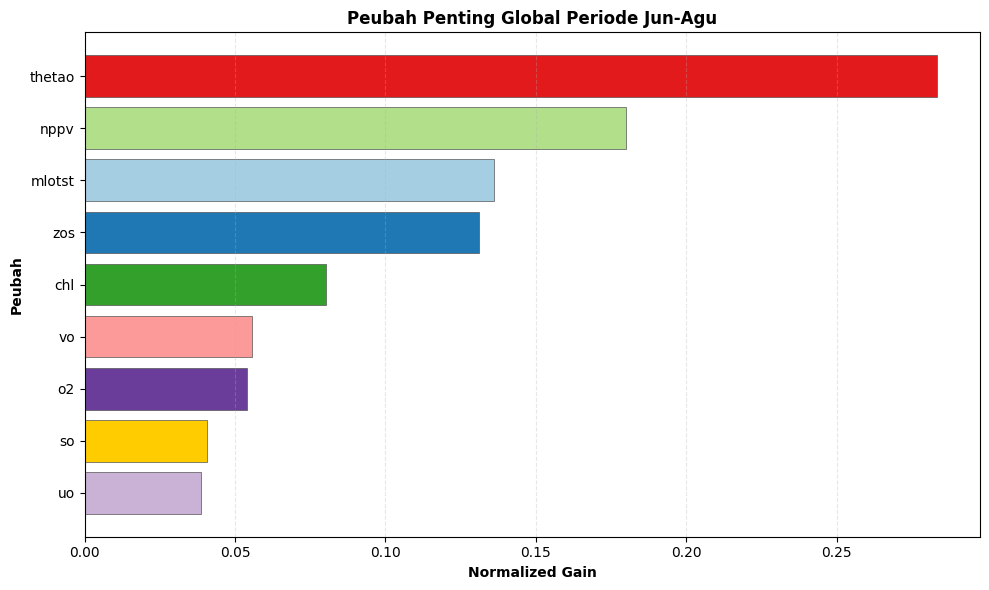

In [ ]:
import matplotlib.pyplot as plt

global_imp = output_model3['GlobalImportance'].copy()

global_imp = global_imp.sort_values(
    by='Gain_Normalized',
    ascending=False
).reset_index(drop=True)

# Mapping warna fitur
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# Warna bar sesuai nama Feature
bar_colors = [
    colors_feature.get(feature, '#bdbdbd')
    for feature in global_imp['Feature']
]

plt.figure(figsize=(10, 6))

plt.barh(
    global_imp['Feature'],
    global_imp['Gain_Normalized'],
    color=bar_colors,
    edgecolor='#555555',
    linewidth=0.5
)

plt.gca().invert_yaxis()

plt.xlabel('Normalized Gain', fontweight='bold')
plt.ylabel('Peubah', fontweight='bold')
plt.title('Peubah Penting Global Periode Jun-Agu', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Peubah Penting Lokal

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# daftar unik fitur
fitur_unik = visual2['Max_Fitur_Bisquare'].unique()

# colormap
cmap = plt.cm.get_cmap('tab10', len(fitur_unik))

# mapping warna
color_map = {fitur: cmap(i) for i, fitur in enumerate(fitur_unik)}

# buat kolom warna
visual2['color'] = visual2['Max_Fitur_Bisquare'].map(color_map)

/tmp/ipykernel_17068/1728261176.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(fitur_unik))


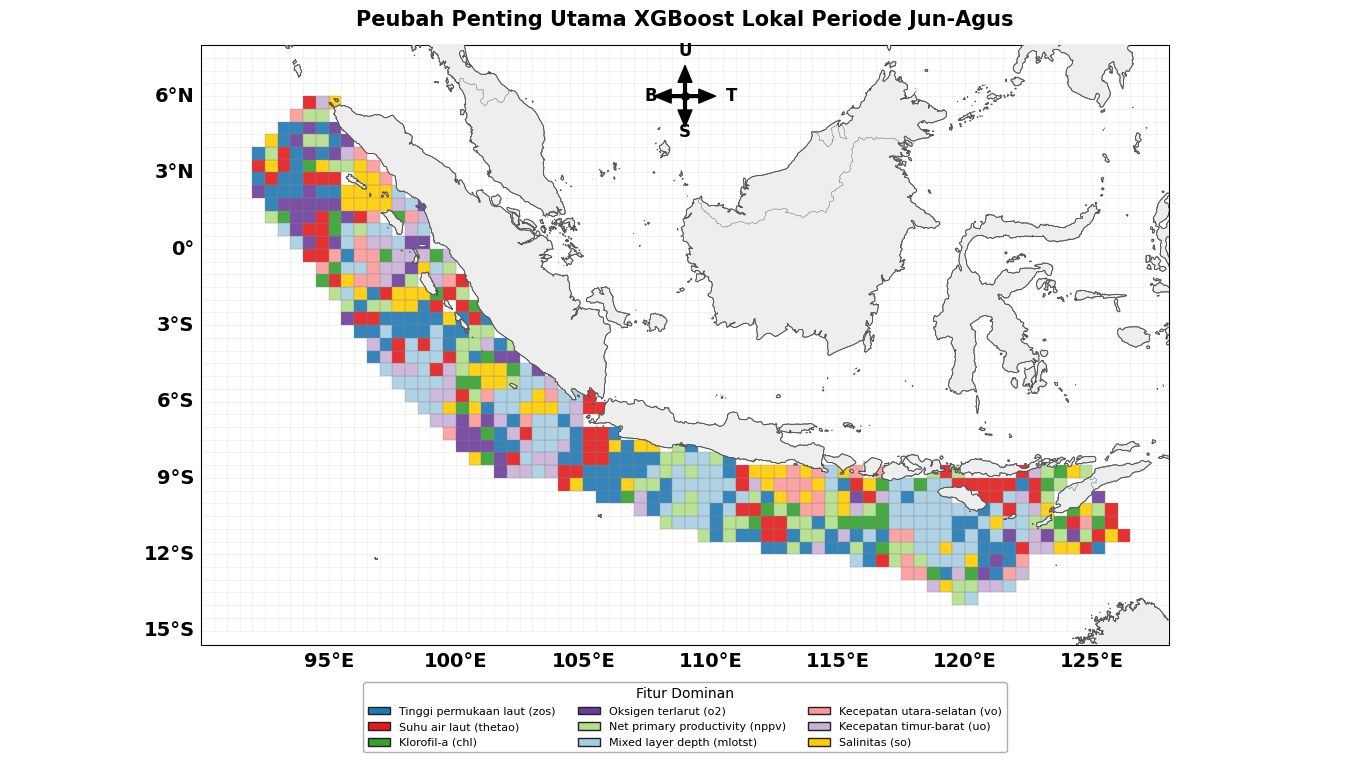

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# 1. PARAMETER PETA
# =========================
feature_col = 'Max_Fitur_Bisquare'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual2.copy()

plot_data['Longitude'] = pd.to_numeric(
    plot_data['Longitude'],
    errors='coerce'
)

plot_data['Latitude'] = pd.to_numeric(
    plot_data['Latitude'],
    errors='coerce'
)

plot_data = plot_data.dropna(
    subset=['Longitude', 'Latitude', feature_col]
)

# =========================
# 2. WARNA FITUR DOMINAN
# =========================
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# =========================
# 3. LABEL FITUR
# =========================
feature_labels = {
    'zos': 'Tinggi permukaan laut (zos)',
    'thetao': 'Suhu air laut (thetao)',
    'chl': 'Klorofil-a (chl)',
    'o2': 'Oksigen terlarut (o2)',
    'nppv': 'Net primary productivity (nppv)',
    'mlotst': 'Mixed layer depth (mlotst)',
    'vo': 'Kecepatan utara-selatan (vo)',
    'uo': 'Kecepatan timur-barat (uo)',
    'so': 'Salinitas (so)'
}

feature_order = [
    'zos',
    'thetao',
    'chl',
    'o2',
    'nppv',
    'mlotst',
    'vo',
    'uo',
    'so'
]

plot_data['color'] = (
    plot_data[feature_col]
    .map(colors_feature)
    .fillna('#bdbdbd')
)

# =========================
# 4. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.05, 0.02, 0.90, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 5. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 6. PLOT GRID FITUR DOMINAN
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    warna = row['color']

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=warna,
        edgecolor='#8a8a8a',
        linewidth=0.25,
        alpha=0.9,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 7. DARATAN DAN BATAS
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 8. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 14,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 14,
    'weight': 'bold'
}

# =========================
# 9. LEGENDE HORIZONTAL
# =========================
fitur_ada = plot_data[feature_col].unique()

legend_patches = [
    patches.Patch(
        facecolor=colors_feature.get(fitur, '#bdbdbd'),
        edgecolor='#222222',
        label=feature_labels.get(fitur, fitur)
    )
    for fitur in feature_order
    if fitur in fitur_ada
]

legend_ax.legend(
    handles=legend_patches,
    title='Fitur Dominan',
    loc='center',
    ncol=3,
    frameon=True,
    edgecolor='#999999',
    fontsize=8,
    title_fontsize=10
)

# =========================
# 10. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 11. JUDUL
# =========================
ax.set_title(
    'Peubah Penting Utama XGBoost Lokal Periode Jun-Agus',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

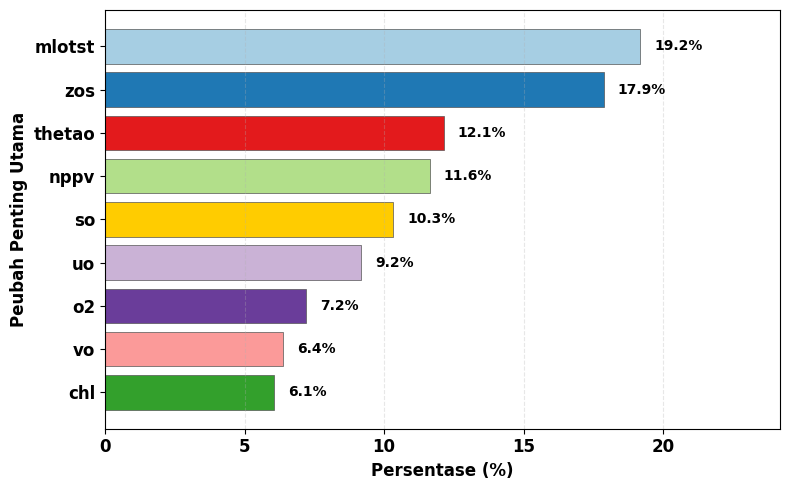

In [ ]:
import matplotlib.pyplot as plt

# 1. Hitung persentase
freq_pct = visual2['Max_Fitur_Bisquare'].value_counts(normalize=True) * 100

# 2. Urutkan (biar terbesar di atas)
freq_pct_sorted = freq_pct.sort_values(ascending=True)

# 3. Gunakan mapping warna yang sama dengan peta
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# Buat list warna sesuai urutan fitur yang sudah diurutkan
bar_colors = [colors_feature.get(feature, '#bdbdbd') for feature in freq_pct_sorted.index]

# 4. Plot
plt.figure(figsize=(8,5))

bars = plt.barh(
    freq_pct_sorted.index,
    freq_pct_sorted.values,
    color=bar_colors,      # Menggunakan mapping warna sinkron
    edgecolor='#555555',
    linewidth=0.5
)

plt.xlabel('Persentase (%)', fontsize = 12, fontweight='bold')
plt.ylabel('Peubah Penting Utama', fontsize=12, fontweight='bold')
plt.setp(plt.gca().get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(plt.gca().get_yticklabels(), fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)

# 5. Label persen di ujung bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, freq_pct_sorted.max() + 5) # Beri ruang untuk label teks
plt.tight_layout()
plt.show()